# 📊 Systematic Literature Review — Data Analysis
# *"What's There to Flex?" Cybercrime Glorification & Youth Radicalisation*

---

This notebook performs comprehensive bibliometric and thematic analysis on the **71 final studies** included in the SLR, drawn from an initial pool of **853 unique records** (917 exported, 64 duplicates removed).

**Analyses performed:**
1. PRISMA Flow Diagram (Screening Pipeline)
2. Publication Year Distribution (Temporal Trends)
3. Database Contribution Analysis
4. Study Design / Methodology Distribution
5. Crime Type Distribution
6. Glorification Level Analysis
7. Geographic Distribution (Country Analysis)
8. Glorification Level × Crime Type Heatmap
9. Glorification Level × Study Design Crosstab
10. Temporal Evolution of Glorification Focus
11. Top Journals / Sources
12. Word Cloud from Titles
13. Summary Statistics Table

## 0. Setup & Data Loading

In [1]:
# Install dependencies (uncomment if running on Colab)
# !pip install openpyxl wordcloud matplotlib seaborn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Set global style
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white'
})

# Color palette
COLORS = {
    'primary': '#1B2838',
    'accent': '#E63946',
    'blue': '#457B9D',
    'light_blue': '#A8DADC',
    'cream': '#F1FAEE',
    'gold': '#E9C46A',
    'green': '#2A9D8F',
    'orange': '#F4A261',
    'purple': '#6D597A',
    'dark': '#264653'
}
PALETTE = [COLORS['accent'], COLORS['blue'], COLORS['gold'], COLORS['green'],
           COLORS['orange'], COLORS['purple'], COLORS['light_blue'], COLORS['primary']]

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


In [2]:
# ---- LOAD DATA ----
# Update the filepath below if needed
FILEPATH = '/Currently_ Working_SLR_71_Studies_FINAL_CLEAN-3.xlsx'

# For Google Colab, uncomment the two lines below to upload the file:
# from google.colab import files
# uploaded = files.upload()

all_records = pd.read_excel(FILEPATH, sheet_name='All 853 Records')
duplicates = pd.read_excel(FILEPATH, sheet_name='Duplicate Identification')
pipeline = pd.read_excel(FILEPATH, sheet_name='Screening Pipeline')
final_71 = pd.read_excel(FILEPATH, sheet_name='Final 71 Studies')
db_breakdown = pd.read_excel(FILEPATH, sheet_name='Database Breakdown')

# Clean final_71 — keep only rows with valid numeric IDs (removes summary rows at bottom)
final_71 = final_71[pd.to_numeric(final_71['ID'], errors='coerce').notna()].copy()
final_71['ID'] = final_71['ID'].astype(int)

# Extract year from 'Authors (Year)' column
final_71['Year'] = final_71['Authors (Year)'].str.extract(r'\((\d{4})\)').astype(float)

print(f'Total records in all_records sheet: {len(all_records)}')
print(f'Total studies in Final 71 sheet: {len(final_71)}')
print(f'Year range: {int(final_71["Year"].min())} – {int(final_71["Year"].max())}')
final_71.head()

Total records in all_records sheet: 860
Total studies in Final 71 sheet: 71
Year range: 1990 – 2026


,ID,Authors (Year),Title,Source/Journal,Design,Crime Type,Glorification Level,Country,Year
0,1,Thomas (2002),Hacker Culture,Univ. Minnesota Press,Ethnography,Cybercrime,Peripheral,USA,2002.0
1,2,Jordan & Taylor (1998),A Sociology of Hackers,"Sociological Review, 46(4)",Qualitative,Cybercrime,Peripheral,UK,1998.0
2,3,Postmodernist (1990),A postmodernist interpretation of the computer...,Academic journal,Theoretical,Cybercrime,Peripheral,USA,1990.0
3,4,Holt (2005),"Hacks, Cracks, and Crime","PhD Dissertation, UMSL",Qualitative,Cybercrime,Peripheral,USA,2005.0
4,5,Turgeman-Goldschmidt (2005),Hackers' Accounts,"Social Science Computer Review, 23(1)",Qualitative,Cybercrime,Tangential,Israel,2005.0


---
## 1. PRISMA Flow Diagram

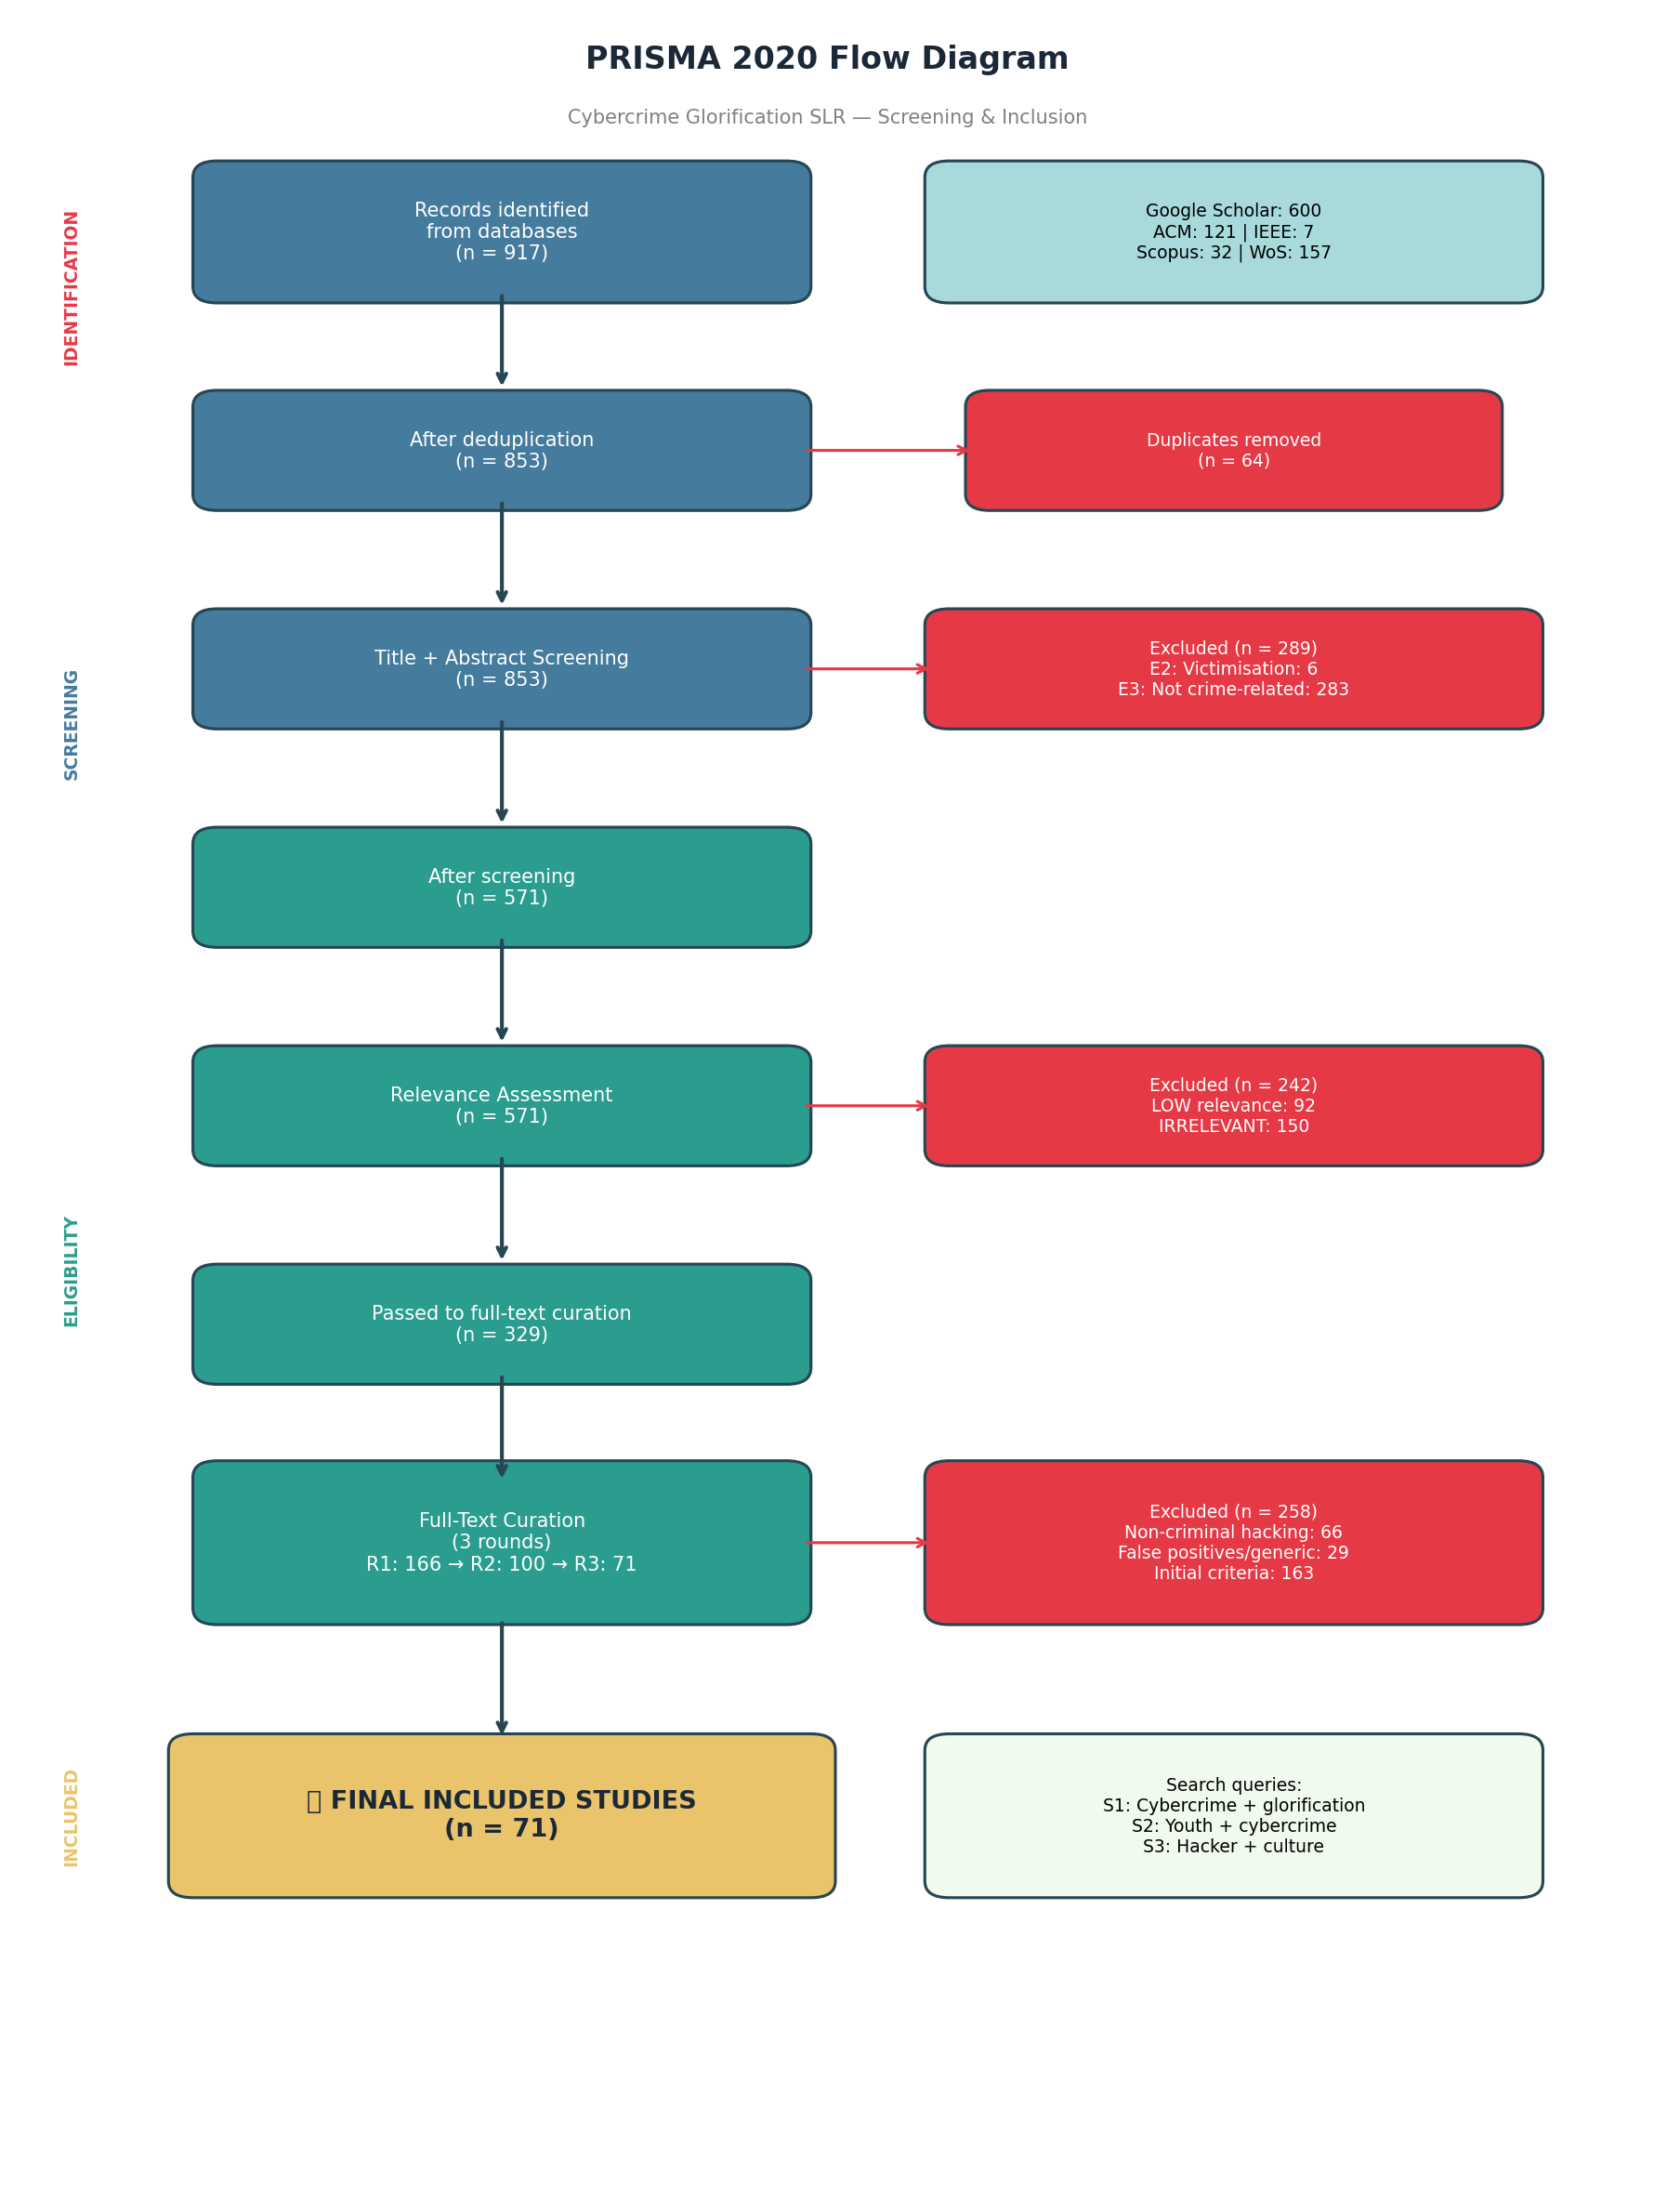

✅ PRISMA flow diagram saved.


In [3]:
fig, ax = plt.subplots(figsize=(12, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('white')

def draw_box(ax, x, y, w, h, text, color='#457B9D', text_color='white', fontsize=10, bold=False):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.15', facecolor=color,
                          edgecolor='#264653', linewidth=1.5)
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight=weight, wrap=True,
            bbox=dict(boxstyle='round,pad=0', facecolor='none', edgecolor='none'))

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#264653', lw=2))

# --- IDENTIFICATION ---
ax.text(5, 19.5, 'PRISMA 2020 Flow Diagram', ha='center', fontsize=16, fontweight='bold', color=COLORS['primary'])
ax.text(5, 19.0, 'Cybercrime Glorification SLR — Screening & Inclusion', ha='center', fontsize=10, color='gray')

# Stage labels on left
ax.text(0.3, 17.5, 'IDENTIFICATION', fontsize=9, fontweight='bold', color=COLORS['accent'], rotation=90, va='center')
ax.text(0.3, 13.5, 'SCREENING', fontsize=9, fontweight='bold', color=COLORS['blue'], rotation=90, va='center')
ax.text(0.3, 8.5, 'ELIGIBILITY', fontsize=9, fontweight='bold', color=COLORS['green'], rotation=90, va='center')
ax.text(0.3, 3.5, 'INCLUDED', fontsize=9, fontweight='bold', color=COLORS['gold'], rotation=90, va='center')

# Identification
draw_box(ax, 3, 18, 3.5, 1.0, 'Records identified\nfrom databases\n(n = 917)', COLORS['blue'])
draw_box(ax, 7.5, 18, 3.5, 1.0, 'Google Scholar: 600\nACM: 121 | IEEE: 7\nScopus: 32 | WoS: 157', '#A8DADC', 'black', 9)

draw_arrow(ax, 3, 17.45, 3, 16.55)

# Deduplication
draw_box(ax, 3, 16, 3.5, 0.8, 'After deduplication\n(n = 853)', COLORS['blue'])
draw_box(ax, 7.5, 16, 3.0, 0.8, 'Duplicates removed\n(n = 64)', COLORS['accent'], 'white', 9)
ax.annotate('', xy=(5.9, 16), xytext=(4.85, 16), arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

draw_arrow(ax, 3, 15.55, 3, 14.55)

# Screening
draw_box(ax, 3, 14, 3.5, 0.8, 'Title + Abstract Screening\n(n = 853)', COLORS['blue'])
draw_box(ax, 7.5, 14, 3.5, 0.8, 'Excluded (n = 289)\nE2: Victimisation: 6\nE3: Not crime-related: 283', COLORS['accent'], 'white', 9)
ax.annotate('', xy=(5.65, 14), xytext=(4.85, 14), arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

draw_arrow(ax, 3, 13.55, 3, 12.55)

# After screening
draw_box(ax, 3, 12, 3.5, 0.8, 'After screening\n(n = 571)', COLORS['green'])

draw_arrow(ax, 3, 11.55, 3, 10.55)

# Relevance assessment
draw_box(ax, 3, 10, 3.5, 0.8, 'Relevance Assessment\n(n = 571)', COLORS['green'])
draw_box(ax, 7.5, 10, 3.5, 0.8, 'Excluded (n = 242)\nLOW relevance: 92\nIRRELEVANT: 150', COLORS['accent'], 'white', 9)
ax.annotate('', xy=(5.65, 10), xytext=(4.85, 10), arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

draw_arrow(ax, 3, 9.55, 3, 8.55)

# After relevance
draw_box(ax, 3, 8, 3.5, 0.8, 'Passed to full-text curation\n(n = 329)', COLORS['green'])

draw_arrow(ax, 3, 7.55, 3, 6.55)

# Full-text curation
draw_box(ax, 3, 6, 3.5, 1.2, 'Full-Text Curation\n(3 rounds)\nR1: 166 → R2: 100 → R3: 71', COLORS['green'])
draw_box(ax, 7.5, 6, 3.5, 1.2, 'Excluded (n = 258)\nNon-criminal hacking: 66\nFalse positives/generic: 29\nInitial criteria: 163', COLORS['accent'], 'white', 9)
ax.annotate('', xy=(5.65, 6), xytext=(4.85, 6), arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

draw_arrow(ax, 3, 5.3, 3, 4.2)

# Final included
draw_box(ax, 3, 3.5, 3.8, 1.2, '✅ FINAL INCLUDED STUDIES\n(n = 71)', COLORS['gold'], COLORS['primary'], 13, True)

# Info box
draw_box(ax, 7.5, 3.5, 3.5, 1.2, 'Search queries:\nS1: Cybercrime + glorification\nS2: Youth + cybercrime\nS3: Hacker + culture', '#F1FAEE', 'black', 9)

plt.tight_layout()
plt.savefig('01_PRISMA_flow_diagram.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ PRISMA flow diagram saved.')

---
## 2. Publication Year Distribution (Temporal Trends)

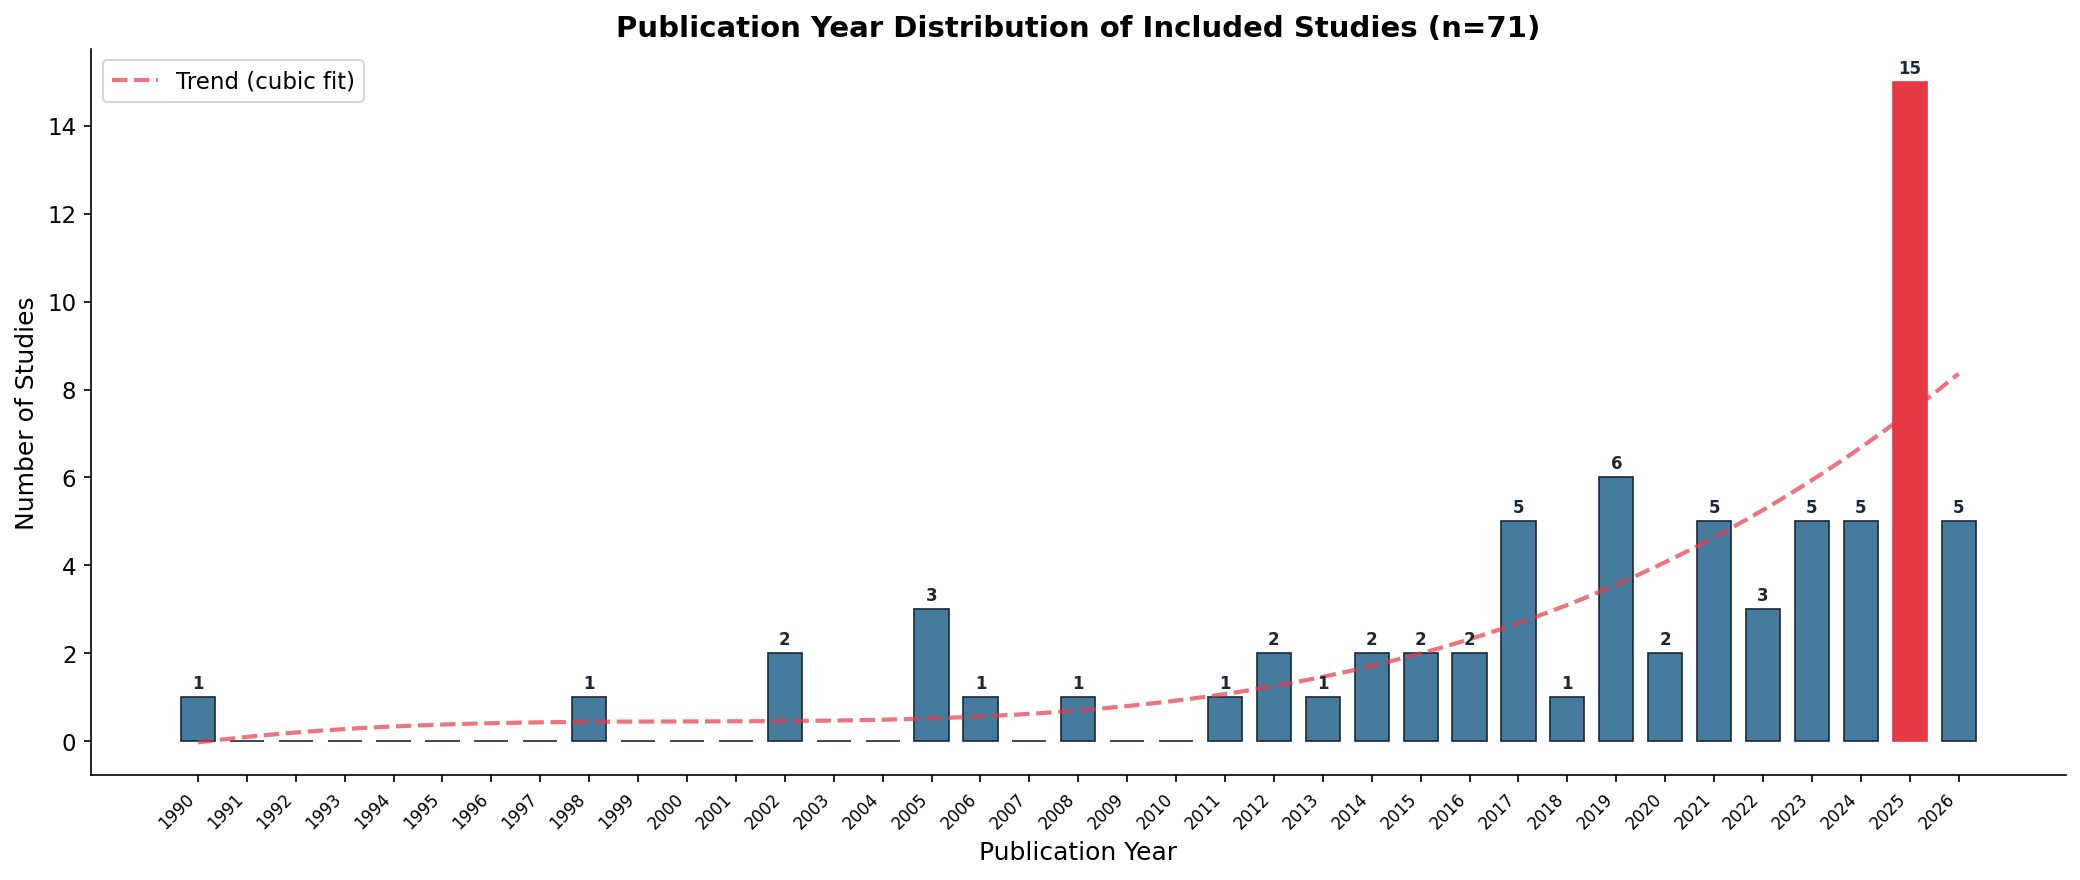


Year range: 1990 – 2026
Peak year: 2025 (15 studies)
Studies 2020–2026: 40 (56.3%)


In [4]:
year_counts = final_71['Year'].dropna().astype(int).value_counts().sort_index()
all_years = range(int(year_counts.index.min()), int(year_counts.index.max()) + 1)
year_counts = year_counts.reindex(all_years, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(year_counts.index, year_counts.values, color=COLORS['blue'],
              edgecolor=COLORS['primary'], linewidth=0.8, width=0.7)

# Highlight peak years
max_val = year_counts.max()
for bar, val in zip(bars, year_counts.values):
    if val >= max_val * 0.7:
        bar.set_color(COLORS['accent'])
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha='center', fontsize=8, fontweight='bold', color=COLORS['primary'])

# Add trend line
z = np.polyfit(year_counts.index, year_counts.values, 3)
p = np.poly1d(z)
x_smooth = np.linspace(year_counts.index.min(), year_counts.index.max(), 100)
ax.plot(x_smooth, p(x_smooth), color=COLORS['accent'], linewidth=2, linestyle='--', alpha=0.7, label='Trend (cubic fit)')

ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Studies')
ax.set_title('Publication Year Distribution of Included Studies (n=71)', fontweight='bold')
ax.set_xticks(year_counts.index)
ax.set_xticklabels(year_counts.index, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('02_publication_year_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

# Print summary
print(f'\nYear range: {int(year_counts.index.min())} – {int(year_counts.index.max())}')
print(f'Peak year: {year_counts.idxmax()} ({year_counts.max()} studies)')
print(f'Studies 2020–2026: {year_counts[year_counts.index >= 2020].sum()} ({year_counts[year_counts.index >= 2020].sum()/len(final_71)*100:.1f}%)')

---
## 3. Database Contribution Analysis

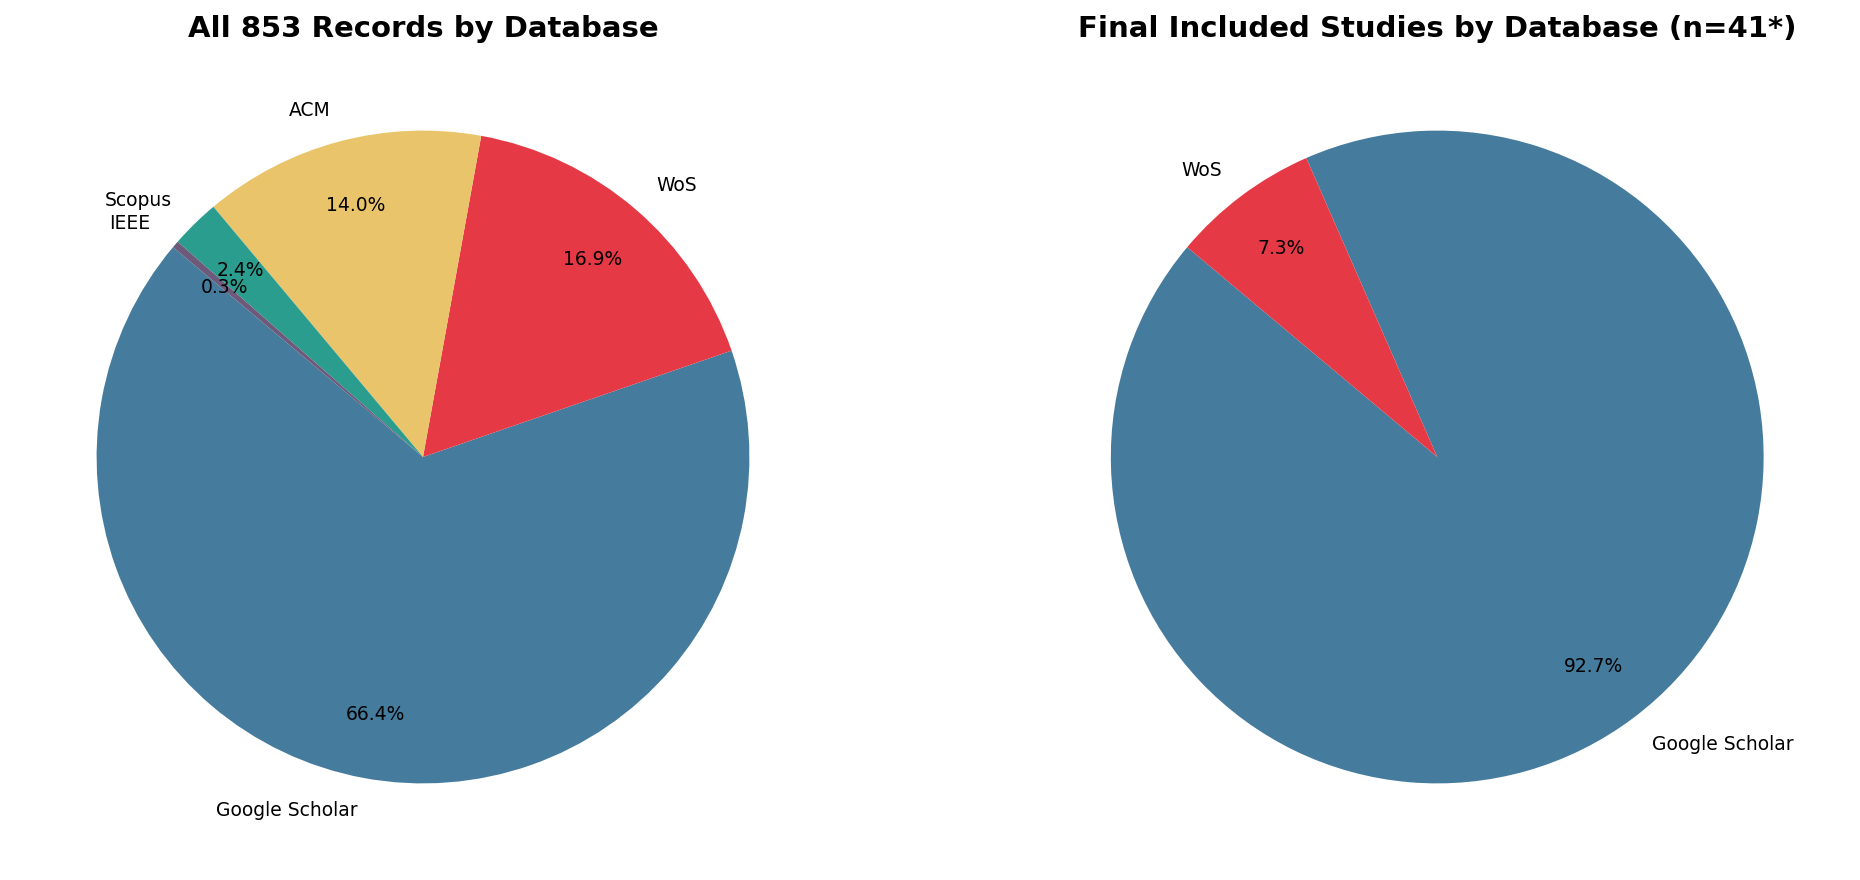

*Note: Only 41 of 71 final studies were tagged in the All 853 sheet.

Database breakdown (all records):
Database
Google Scholar    571
WoS               145
ACM               120
Scopus             21
IEEE                3


In [5]:
# From the All 853 records — count how many of the Final 71 came from each database
final_records = all_records[all_records['Decision'] == 'INCLUDED (Final 71)']
db_counts_final = final_records['Database'].value_counts()

# All 853 by database
db_counts_all = all_records['Database'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: All 853 by database
colors_all = [COLORS['blue'], COLORS['accent'], COLORS['gold'], COLORS['green'], COLORS['purple']]
wedges1, texts1, autotexts1 = axes[0].pie(
    db_counts_all.values, labels=db_counts_all.index, autopct='%1.1f%%',
    colors=colors_all[:len(db_counts_all)], startangle=140,
    textprops={'fontsize': 9}, pctdistance=0.8
)
axes[0].set_title('All 853 Records by Database', fontweight='bold')

# Right: Final 71 by database (from included records in the all records sheet)
wedges2, texts2, autotexts2 = axes[1].pie(
    db_counts_final.values, labels=db_counts_final.index, autopct='%1.1f%%',
    colors=colors_all[:len(db_counts_final)], startangle=140,
    textprops={'fontsize': 9}, pctdistance=0.8
)
axes[1].set_title(f'Final Included Studies by Database (n={len(final_records)}*)', fontweight='bold')

plt.tight_layout()
plt.savefig('03_database_contribution.png', bbox_inches='tight', dpi=300)
plt.show()
print('*Note: Only', len(final_records), 'of 71 final studies were tagged in the All 853 sheet.')
print('\nDatabase breakdown (all records):')
print(db_counts_all.to_string())

---
## 4. Study Design / Methodology Distribution

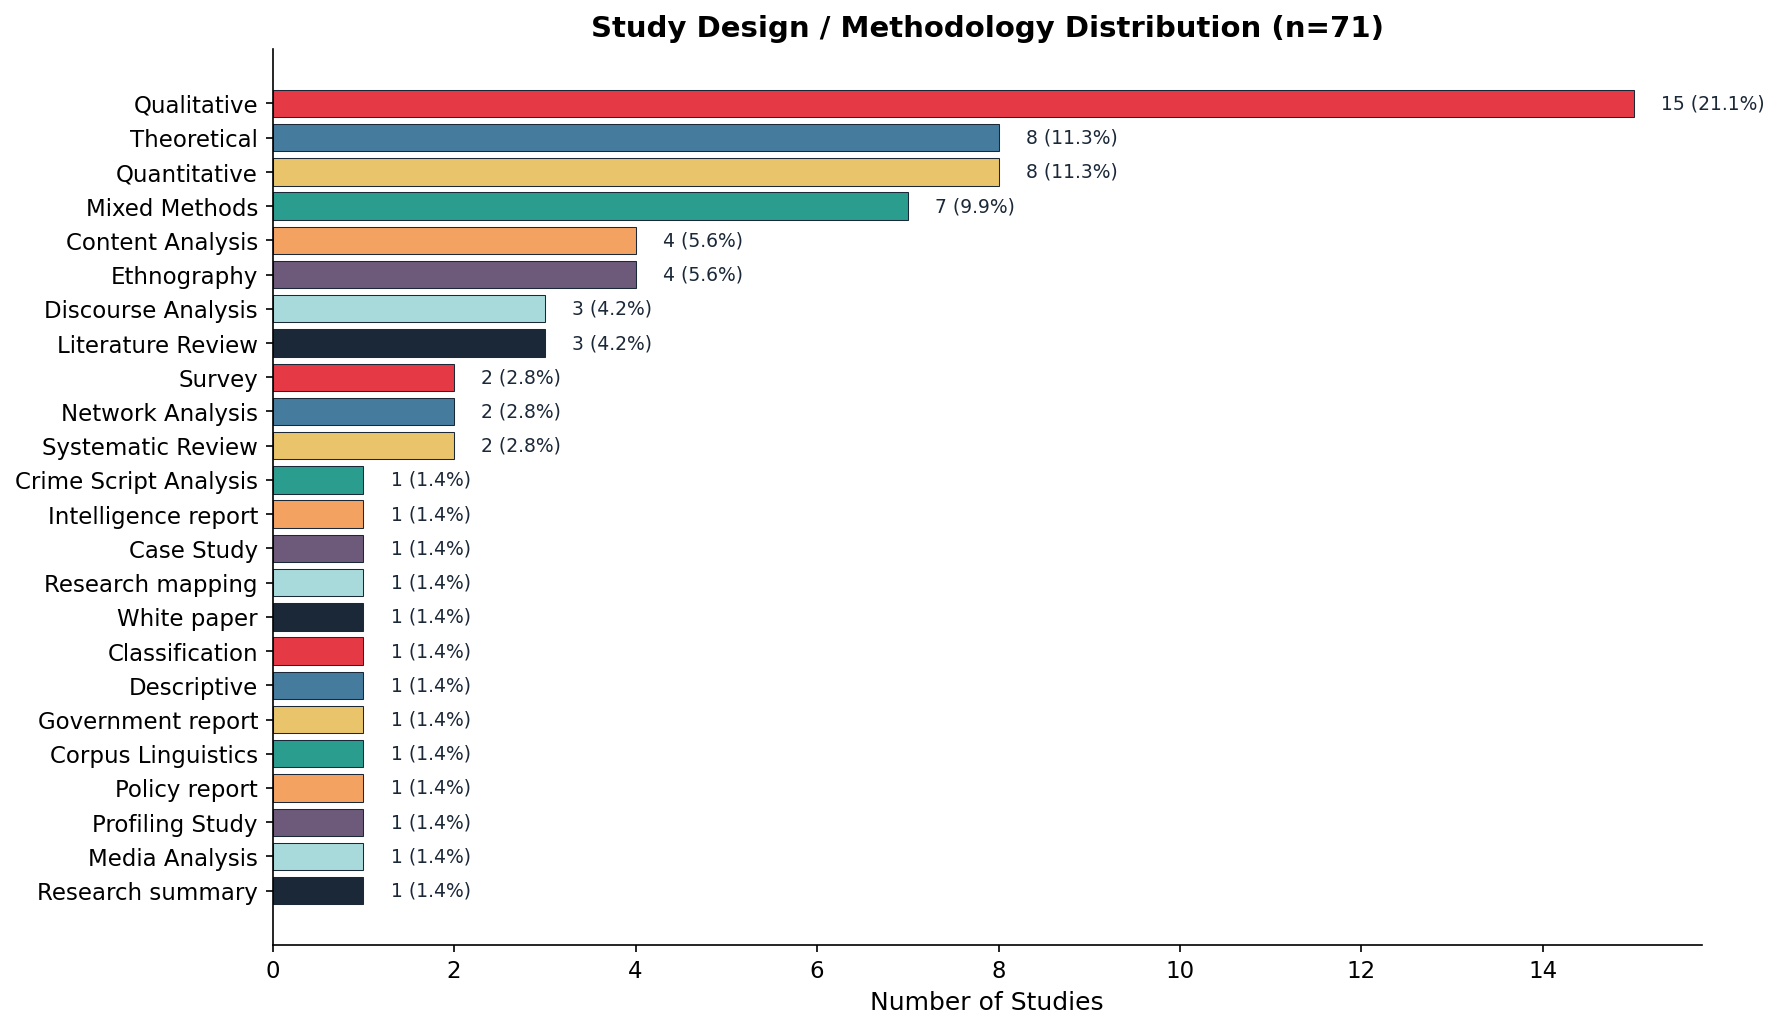

In [6]:
# Clean design categories — merge variants
design_map = {
    'Qualitative': 'Qualitative',
    'Qualitative (n=28)': 'Qualitative',
    'Qualitative (n=7)': 'Qualitative',
    'Quantitative': 'Quantitative',
    'Quantitative (n=1109)': 'Quantitative',
    'Mixed methods': 'Mixed Methods',
    'Ethnography': 'Ethnography',
    'Ethnographic': 'Ethnography',
    'Content analysis': 'Content Analysis',
    'Theoretical': 'Theoretical',
    'Literature review': 'Literature Review',
    'Systematic review': 'Systematic Review',
    'Review': 'Literature Review',
    'Network analysis': 'Network Analysis',
    'Discourse analysis': 'Discourse Analysis',
    'Crime script': 'Crime Script Analysis',
    'Corpus linguistics': 'Corpus Linguistics',
    'Survey': 'Survey',
    'Case study': 'Case Study',
    'Media analysis': 'Media Analysis',
    'Profiling study': 'Profiling Study',
}

final_71['Design_Clean'] = final_71['Design'].map(lambda x: design_map.get(x, x))
design_counts = final_71['Design_Clean'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(design_counts.index[::-1], design_counts.values[::-1],
               color=[PALETTE[i % len(PALETTE)] for i in range(len(design_counts))][::-1],
               edgecolor=COLORS['primary'], linewidth=0.5)

for bar, val in zip(bars, design_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(final_71)*100:.1f}%)', va='center', fontsize=9, color=COLORS['primary'])

ax.set_xlabel('Number of Studies')
ax.set_title('Study Design / Methodology Distribution (n=71)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('04_study_design_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 5. Crime Type Distribution

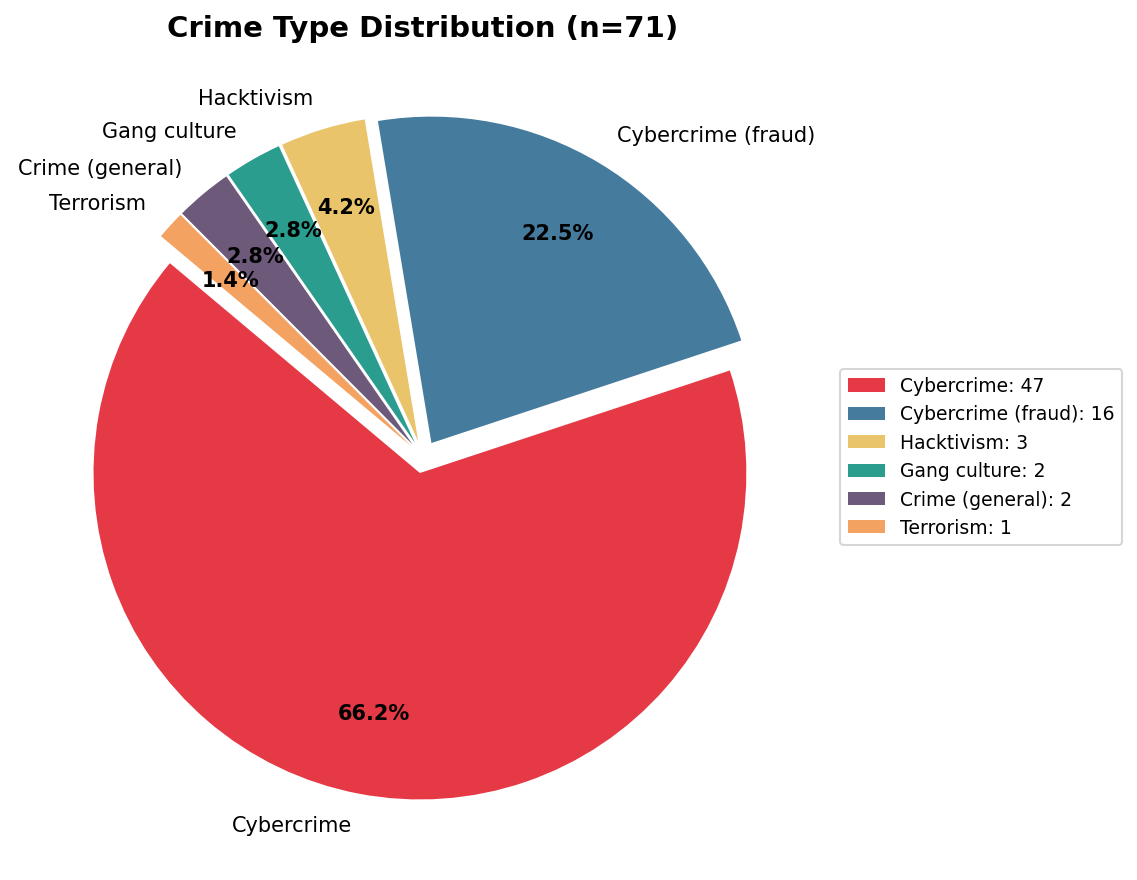

Crime Type Counts:
  Cybercrime: 47 (66.2%)
  Cybercrime (fraud): 16 (22.5%)
  Hacktivism: 3 (4.2%)
  Gang culture: 2 (2.8%)
  Crime (general): 2 (2.8%)
  Terrorism: 1 (1.4%)


In [7]:
crime_counts = final_71['Crime Type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors_crime = [COLORS['accent'], COLORS['blue'], COLORS['gold'], COLORS['green'], COLORS['purple'], COLORS['orange']]
wedges, texts, autotexts = ax.pie(
    crime_counts.values, labels=crime_counts.index, autopct='%1.1f%%',
    colors=colors_crime[:len(crime_counts)], startangle=140,
    textprops={'fontsize': 10}, pctdistance=0.75,
    explode=[0.05]*len(crime_counts)
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

# Add count labels
legend_labels = [f'{name}: {count}' for name, count in zip(crime_counts.index, crime_counts.values)]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

ax.set_title('Crime Type Distribution (n=71)', fontweight='bold')
plt.tight_layout()
plt.savefig('05_crime_type_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print('Crime Type Counts:')
for ct, count in crime_counts.items():
    print(f'  {ct}: {count} ({count/len(final_71)*100:.1f}%)')

---
## 6. Glorification Level Analysis

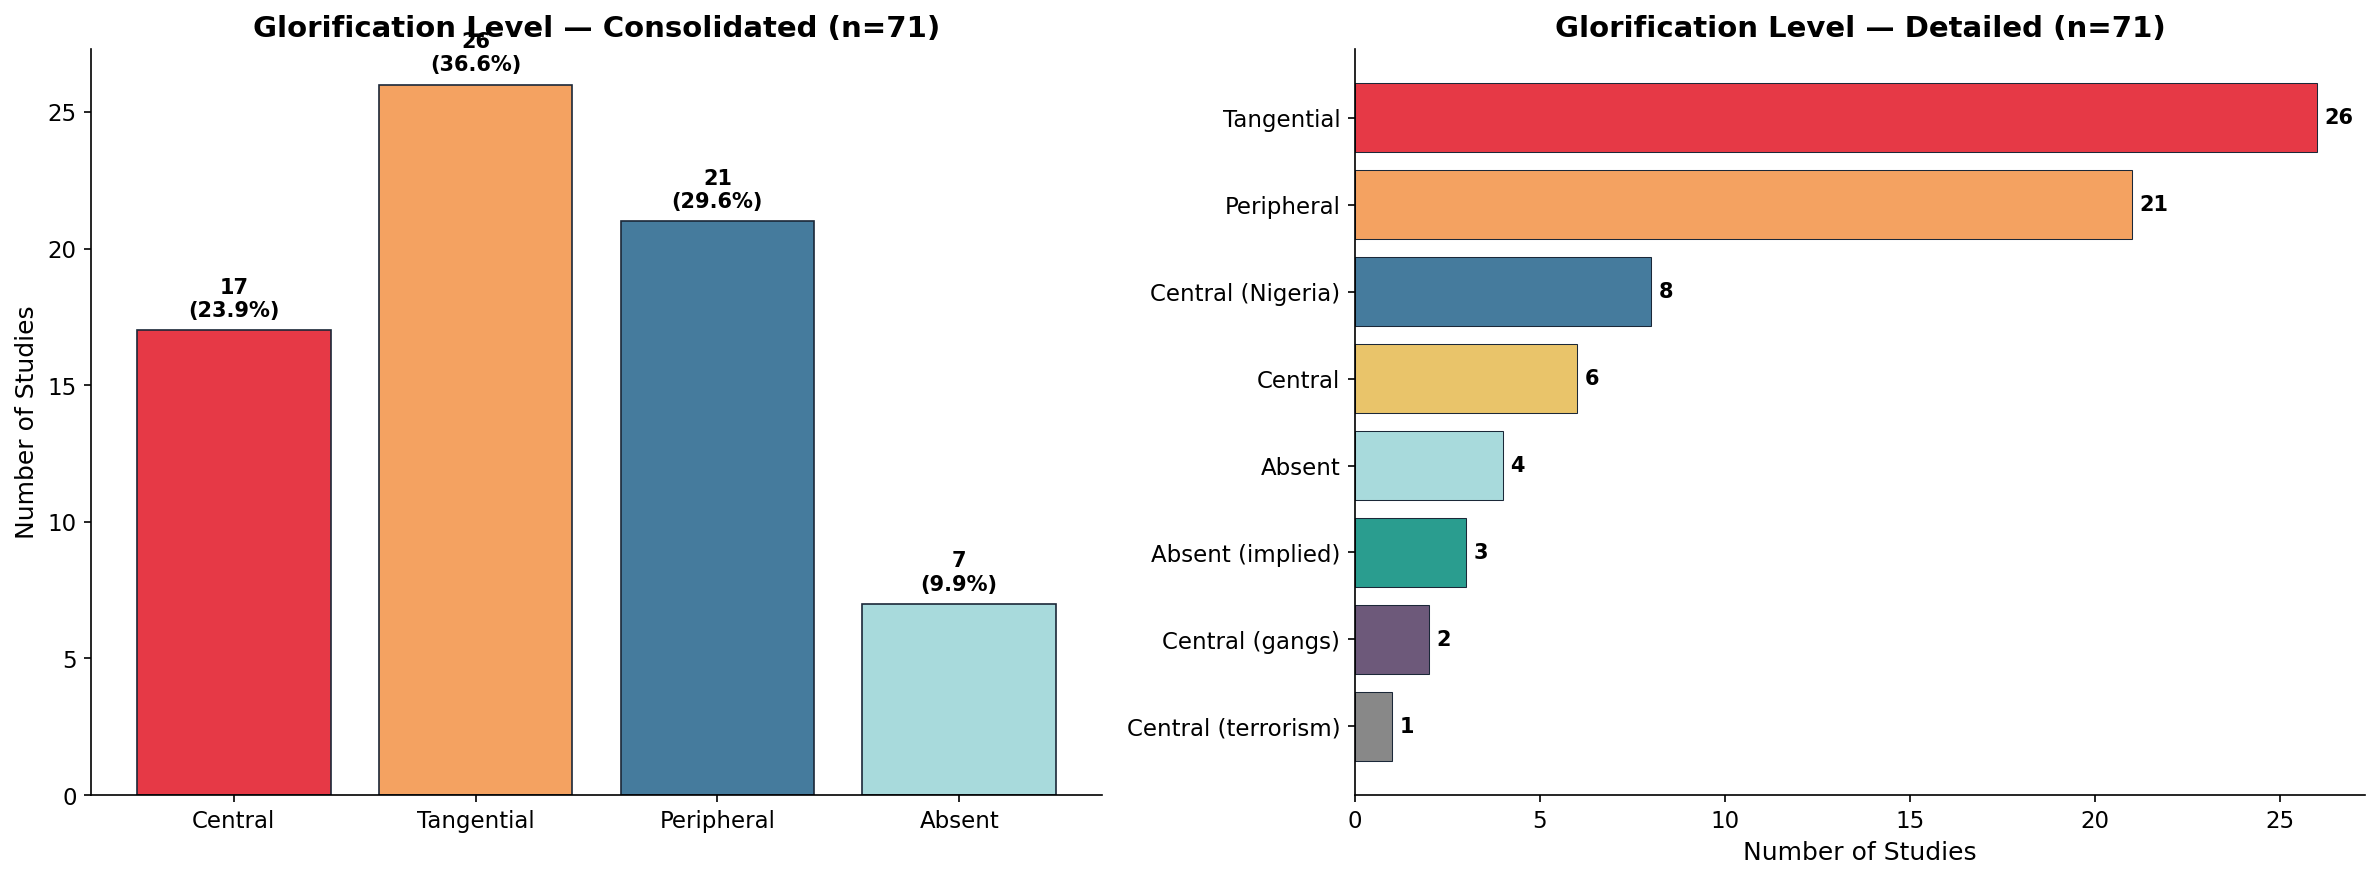

In [8]:
# Clean glorification levels
glor_map = {
    'Central': 'Central',
    'Central (Nigeria)': 'Central',
    'Central (terrorism)': 'Central',
    'Central (gangs)': 'Central',
    'Tangential': 'Tangential',
    'Peripheral': 'Peripheral',
    'Absent': 'Absent',
    'Absent (implied)': 'Absent'
}
final_71['Glor_Clean'] = final_71['Glorification Level'].map(lambda x: glor_map.get(x, x))

# Also keep original for detailed view
glor_detailed = final_71['Glorification Level'].value_counts()
glor_clean = final_71['Glor_Clean'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Consolidated view
order = ['Central', 'Tangential', 'Peripheral', 'Absent']
glor_ordered = glor_clean.reindex(order)
color_map = {'Central': COLORS['accent'], 'Tangential': COLORS['orange'],
             'Peripheral': COLORS['blue'], 'Absent': COLORS['light_blue']}
bar_colors = [color_map[x] for x in order]

bars = axes[0].bar(order, glor_ordered.values, color=bar_colors,
                   edgecolor=COLORS['primary'], linewidth=0.8)
for bar, val in zip(bars, glor_ordered.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}\n({val/len(final_71)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Glorification Level — Consolidated (n=71)', fontweight='bold')
axes[0].set_ylabel('Number of Studies')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Detailed (original) view
detail_colors = [COLORS['accent'], COLORS['orange'], COLORS['blue'],
                 COLORS['gold'], COLORS['light_blue'], COLORS['green'],
                 COLORS['purple'], '#888888']
bars2 = axes[1].barh(glor_detailed.index[::-1], glor_detailed.values[::-1],
                     color=detail_colors[:len(glor_detailed)][::-1],
                     edgecolor=COLORS['primary'], linewidth=0.5)
for bar, val in zip(bars2, glor_detailed.values[::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, fontweight='bold')
axes[1].set_title('Glorification Level — Detailed (n=71)', fontweight='bold')
axes[1].set_xlabel('Number of Studies')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('06_glorification_level.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 7. Geographic Distribution

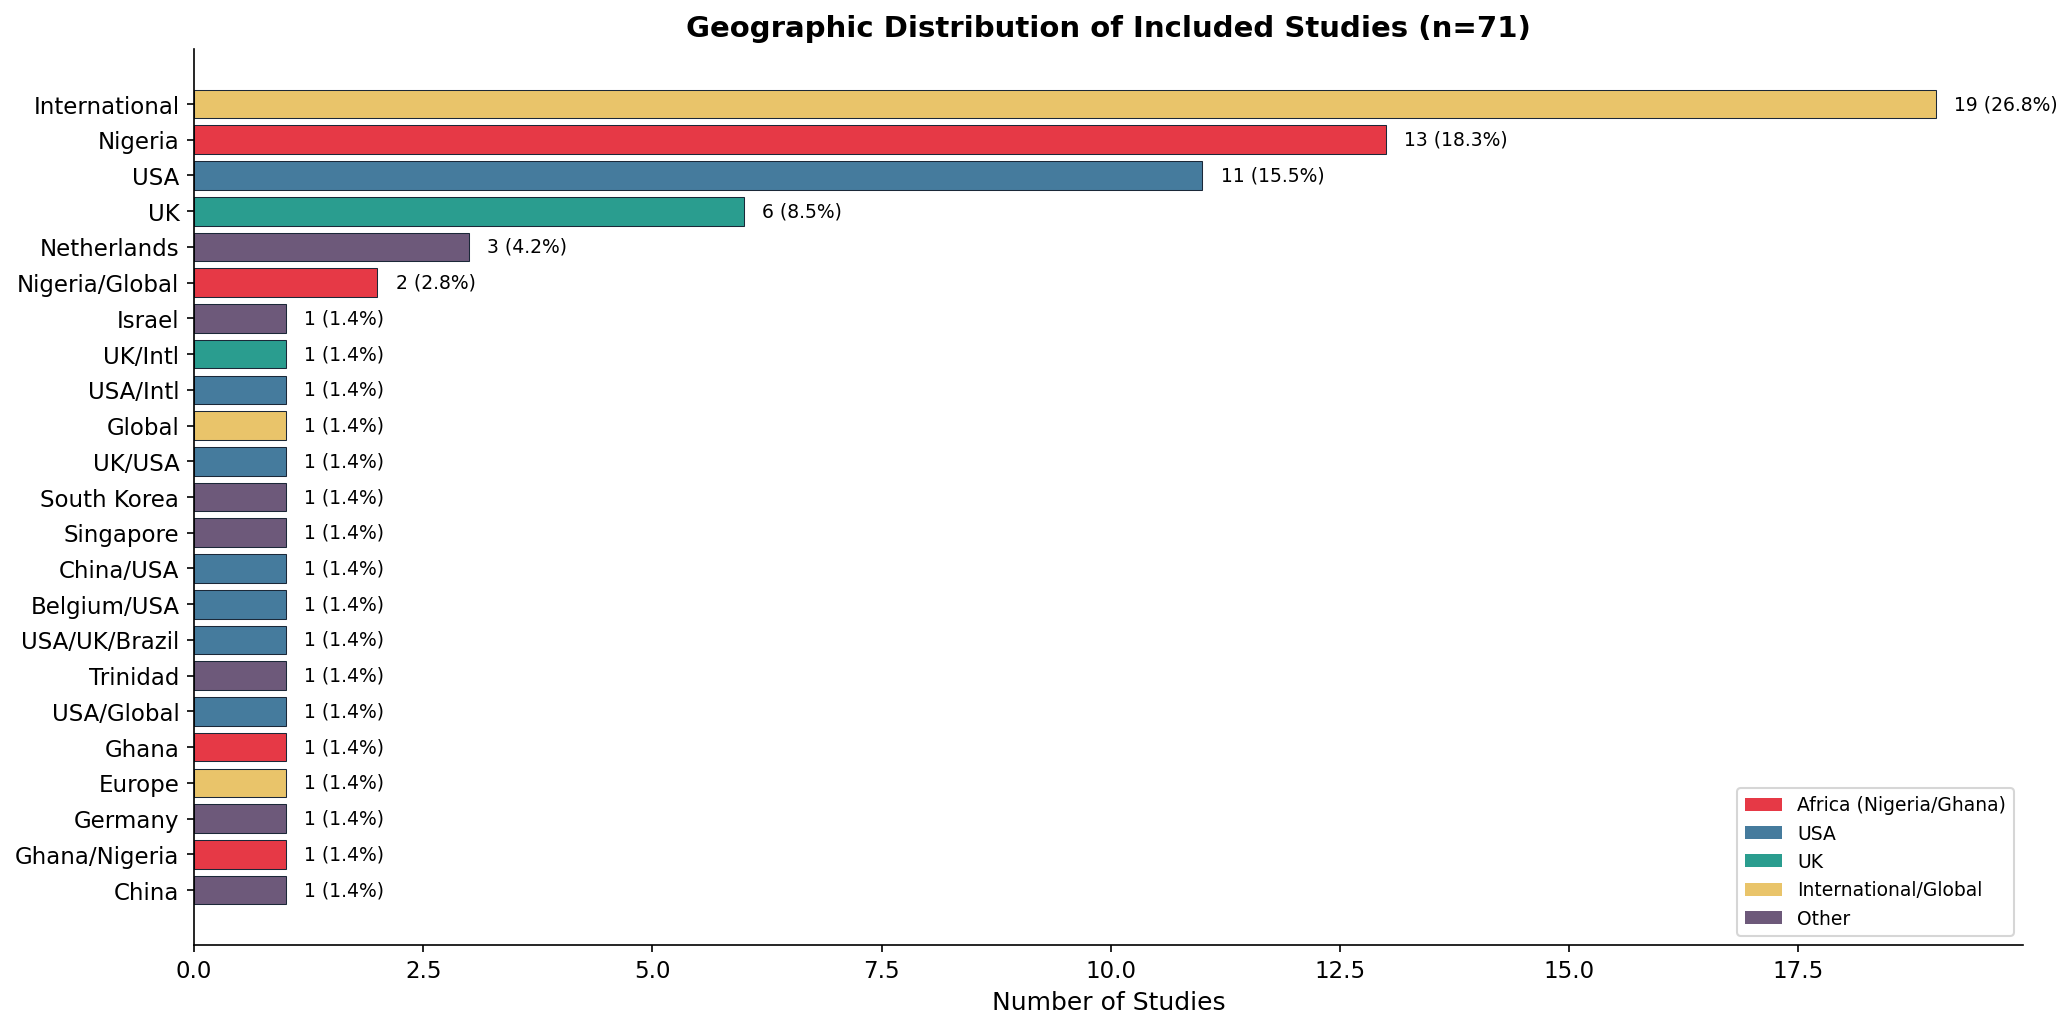

In [9]:
country_counts = final_71['Country'].value_counts()

fig, ax = plt.subplots(figsize=(14, 7))

# Color code by region
def get_region_color(country):
    if 'Nigeria' in str(country) or 'Ghana' in str(country):
        return COLORS['accent']
    elif 'USA' in str(country):
        return COLORS['blue']
    elif 'UK' in str(country):
        return COLORS['green']
    elif 'International' in str(country) or 'Global' in str(country) or 'Europe' in str(country):
        return COLORS['gold']
    else:
        return COLORS['purple']

bar_colors = [get_region_color(c) for c in country_counts.index]
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color=bar_colors[::-1], edgecolor=COLORS['primary'], linewidth=0.5)

for bar, val in zip(bars, country_counts.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(final_71)*100:.1f}%)', va='center', fontsize=9)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLORS['accent'], label='Africa (Nigeria/Ghana)'),
    mpatches.Patch(facecolor=COLORS['blue'], label='USA'),
    mpatches.Patch(facecolor=COLORS['green'], label='UK'),
    mpatches.Patch(facecolor=COLORS['gold'], label='International/Global'),
    mpatches.Patch(facecolor=COLORS['purple'], label='Other'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Number of Studies')
ax.set_title('Geographic Distribution of Included Studies (n=71)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('07_geographic_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 8. Glorification Level × Crime Type Heatmap

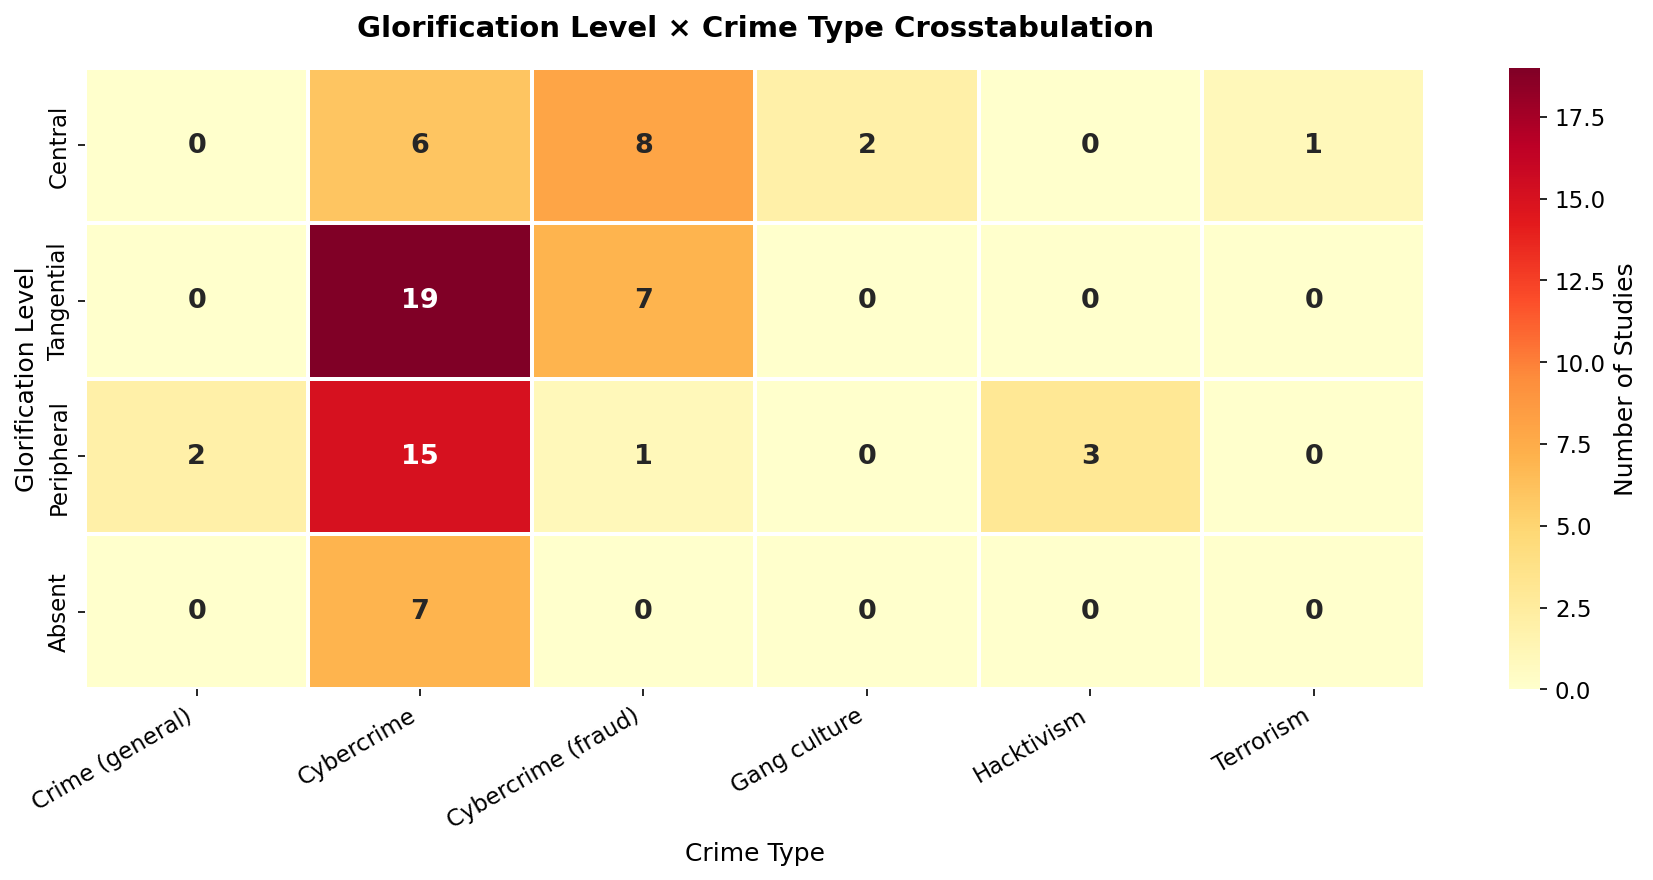


Crosstabulation:
Crime Type  Crime (general)  Cybercrime  Cybercrime (fraud)  Gang culture  Hacktivism  Terrorism
Glor_Clean                                                                                      
Central                   0           6                   8             2           0          1
Tangential                0          19                   7             0           0          0
Peripheral                2          15                   1             0           3          0
Absent                    0           7                   0             0           0          0


In [10]:
cross_tab = pd.crosstab(final_71['Glor_Clean'], final_71['Crime Type'])

# Reorder
row_order = ['Central', 'Tangential', 'Peripheral', 'Absent']
cross_tab = cross_tab.reindex([r for r in row_order if r in cross_tab.index])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=1,
            linecolor='white', ax=ax, cbar_kws={'label': 'Number of Studies'},
            annot_kws={'fontsize': 13, 'fontweight': 'bold'})

ax.set_title('Glorification Level × Crime Type Crosstabulation', fontweight='bold', pad=15)
ax.set_ylabel('Glorification Level')
ax.set_xlabel('Crime Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('08_glorification_crimetype_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

print('\nCrosstabulation:')
print(cross_tab.to_string())

---
## 9. Glorification Level × Study Design Crosstab

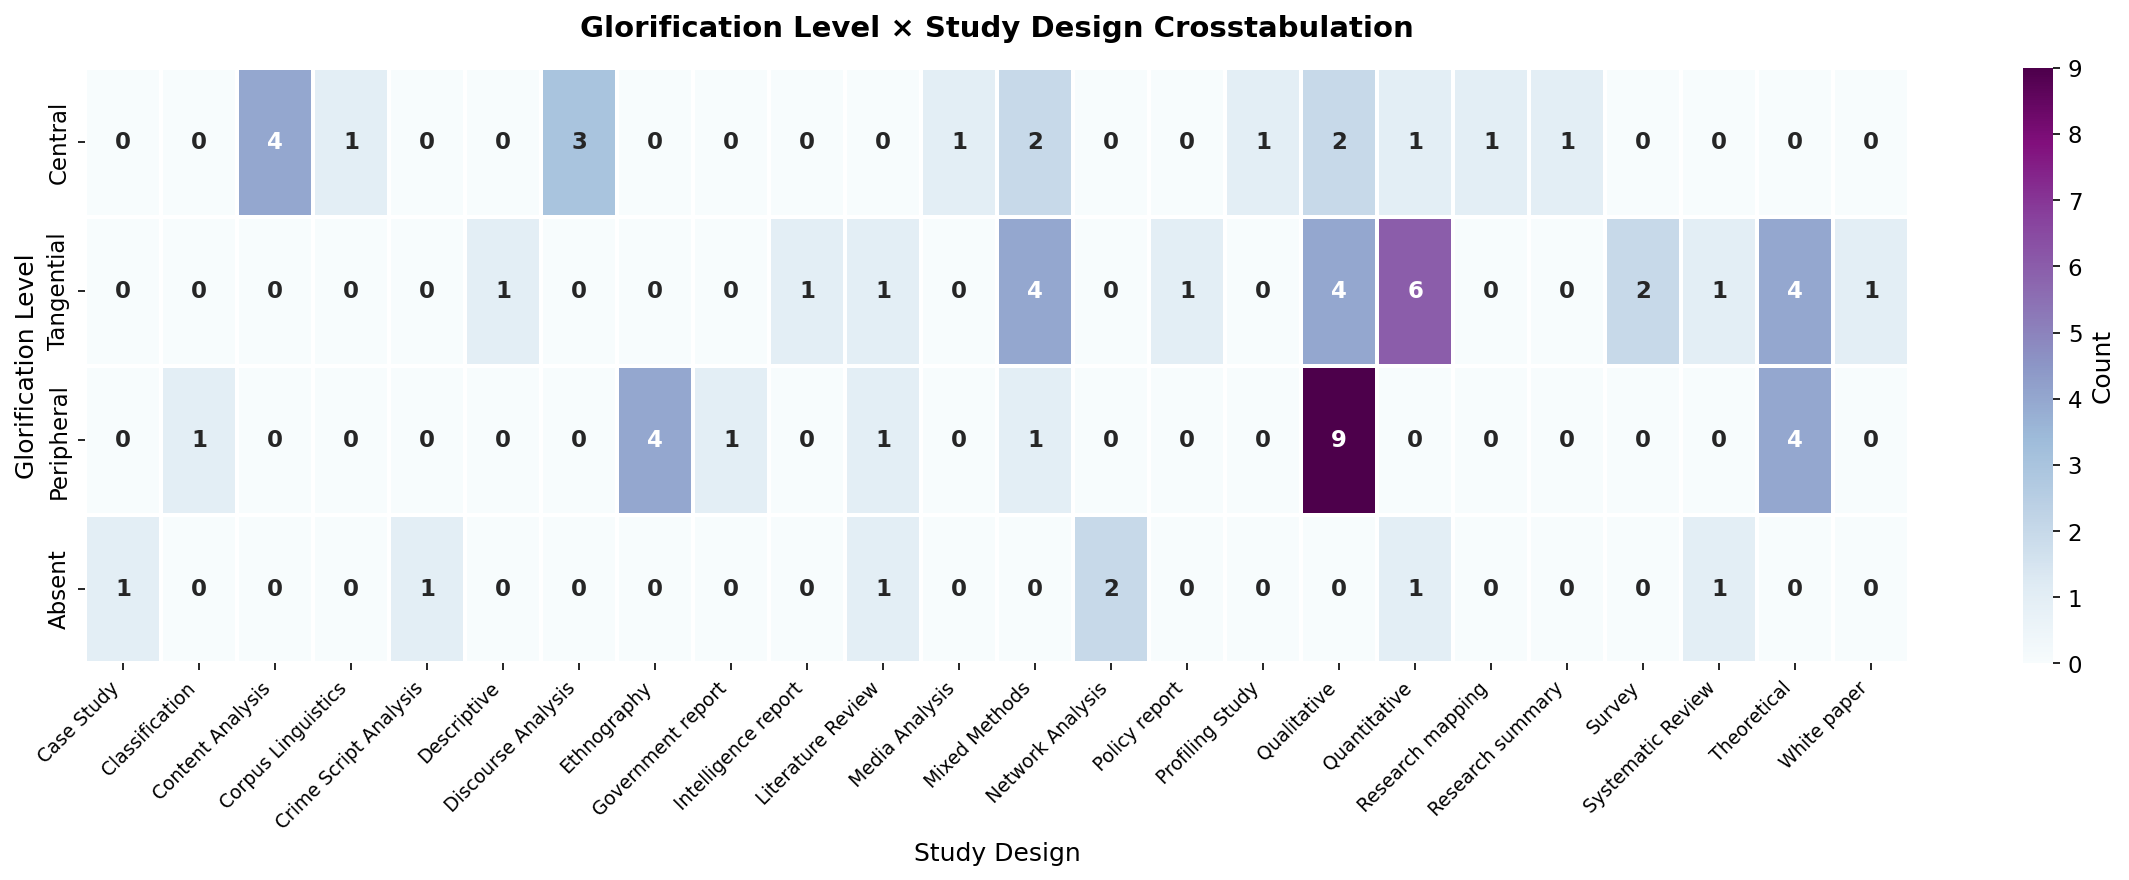

In [11]:
cross_design = pd.crosstab(final_71['Glor_Clean'], final_71['Design_Clean'])
row_order = ['Central', 'Tangential', 'Peripheral', 'Absent']
cross_design = cross_design.reindex([r for r in row_order if r in cross_design.index])

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(cross_design, annot=True, fmt='d', cmap='BuPu', linewidths=1,
            linecolor='white', ax=ax, cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})

ax.set_title('Glorification Level × Study Design Crosstabulation', fontweight='bold', pad=15)
ax.set_ylabel('Glorification Level')
ax.set_xlabel('Study Design')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('09_glorification_design_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 10. Temporal Evolution of Glorification Focus

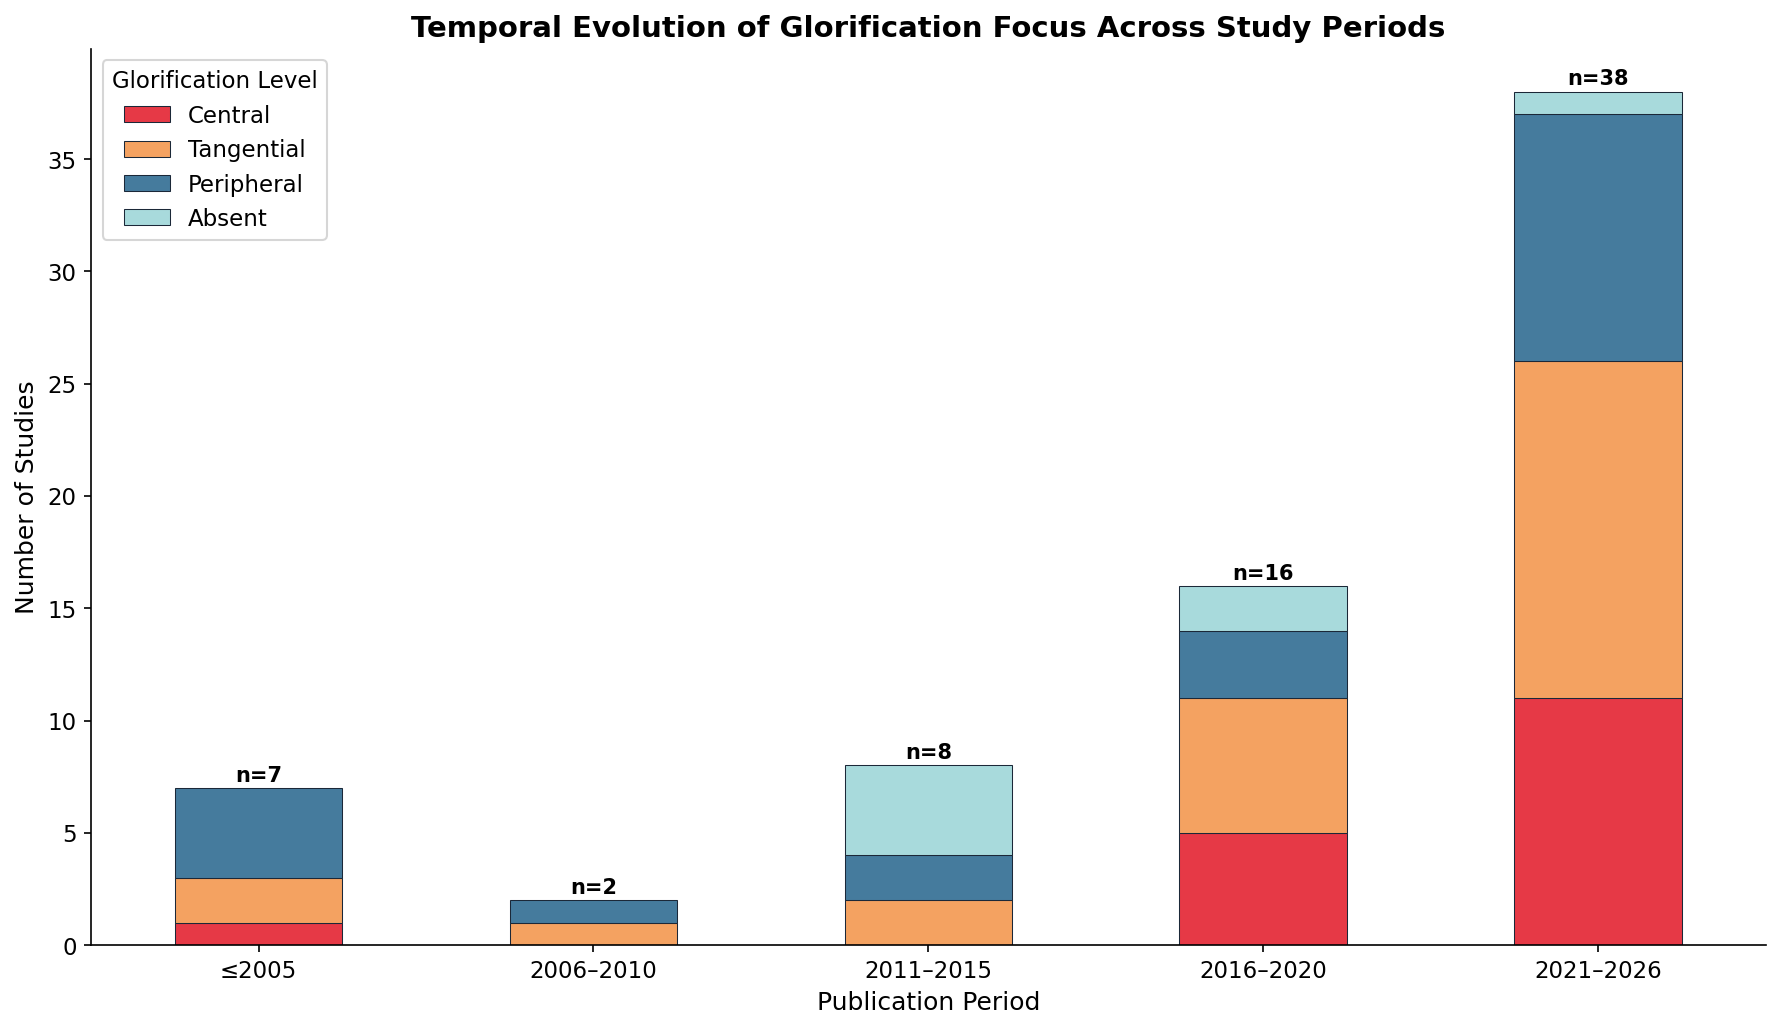


Period × Glorification Level:
Glor_Clean  Central  Tangential  Peripheral  Absent
Period                                             
≤2005             1           2           4       0
2006–2010         0           1           1       0
2011–2015         0           2           2       4
2016–2020         5           6           3       2
2021–2026        11          15          11       1


In [12]:
# Group years into periods for clearer trends
def year_period(year):
    if pd.isna(year): return None
    y = int(year)
    if y <= 2005: return '≤2005'
    elif y <= 2010: return '2006–2010'
    elif y <= 2015: return '2011–2015'
    elif y <= 2020: return '2016–2020'
    else: return '2021–2026'

final_71['Period'] = final_71['Year'].apply(year_period)
period_order = ['≤2005', '2006–2010', '2011–2015', '2016–2020', '2021–2026']

cross_period = pd.crosstab(final_71['Period'], final_71['Glor_Clean'])
cross_period = cross_period.reindex(period_order)
glor_order = ['Central', 'Tangential', 'Peripheral', 'Absent']
cross_period = cross_period[[c for c in glor_order if c in cross_period.columns]]

color_list = [COLORS['accent'], COLORS['orange'], COLORS['blue'], COLORS['light_blue']]

fig, ax = plt.subplots(figsize=(12, 7))
cross_period.plot(kind='bar', stacked=True, color=color_list, ax=ax,
                  edgecolor=COLORS['primary'], linewidth=0.5)

ax.set_title('Temporal Evolution of Glorification Focus Across Study Periods', fontweight='bold')
ax.set_xlabel('Publication Period')
ax.set_ylabel('Number of Studies')
ax.legend(title='Glorification Level', loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=0)

# Add total labels
for i, period in enumerate(period_order):
    if period in cross_period.index:
        total = cross_period.loc[period].sum()
        ax.text(i, total + 0.3, f'n={int(total)}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('10_temporal_glorification_evolution.png', bbox_inches='tight', dpi=300)
plt.show()

print('\nPeriod × Glorification Level:')
print(cross_period.to_string())

---
## 11. Top Journals / Sources

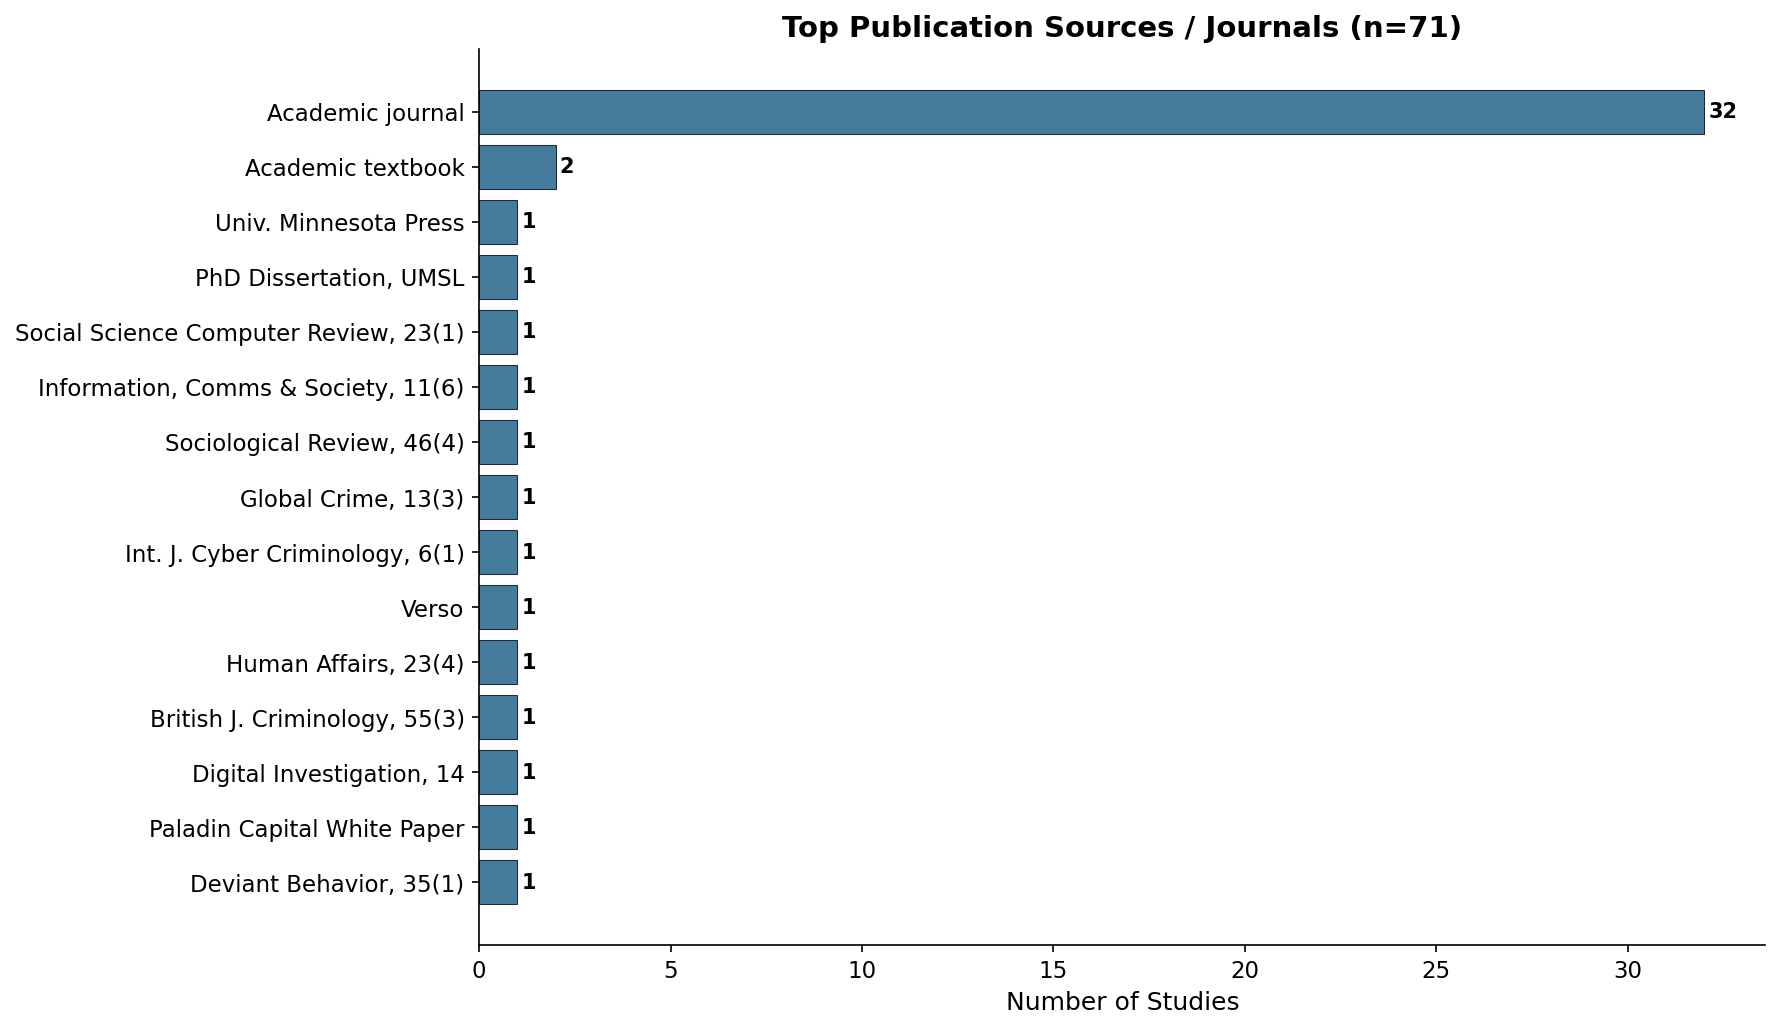


Total unique sources: 39
Studies in "Academic journal" (generic): 32


In [13]:
source_counts = final_71['Source/Journal'].value_counts()
# Show top 15 sources
top_sources = source_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_sources.index[::-1], top_sources.values[::-1],
               color=COLORS['blue'], edgecolor=COLORS['primary'], linewidth=0.5)

for bar, val in zip(bars, top_sources.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Studies')
ax.set_title('Top Publication Sources / Journals (n=71)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('11_top_journals.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'\nTotal unique sources: {len(source_counts)}')
print(f'Studies in "Academic journal" (generic): {source_counts.get("Academic journal", 0)}')

---
## 12. Word Cloud from Study Titles

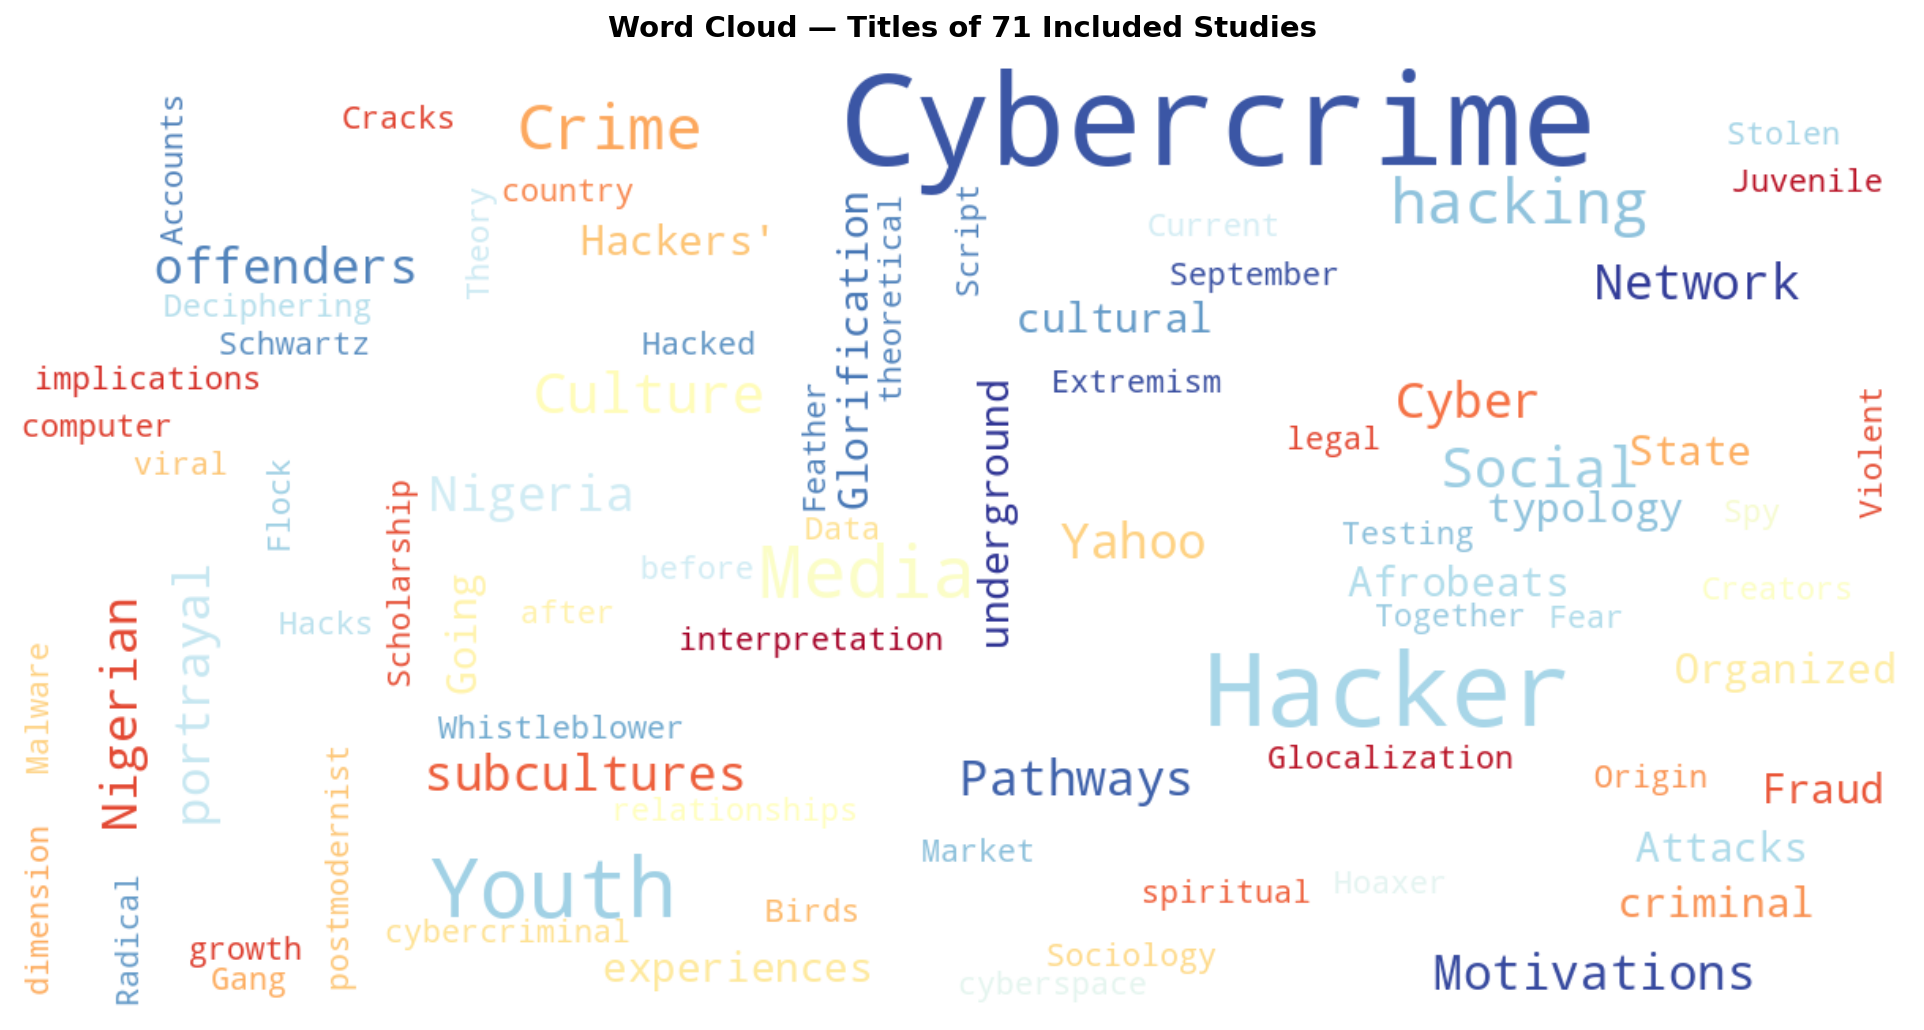

In [14]:
# Combine all titles
titles = ' '.join(final_71['Title'].dropna().tolist())

# Stopwords
stopwords = set(['the', 'of', 'and', 'in', 'a', 'to', 'for', 'an', 'on', 'is',
                 'from', 'with', 'by', 'its', 'their', 'between', 'among', 'into',
                 'how', 'what', 'are', 'as', 'or', 'that', 'this', 'case', 'study',
                 'analysis', 'approach', 'based', 'new', 'role', 'towards', 'review'])

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=80,
    colormap='RdYlBu_r',
    stopwords=stopwords,
    collocations=True,
    min_font_size=12,
    max_font_size=80,
    prefer_horizontal=0.7
).generate(titles)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Titles of 71 Included Studies', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('12_word_cloud_titles.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 13. Summary Statistics Table

In [15]:
print('=' * 65)
print('  SYSTEMATIC LITERATURE REVIEW — SUMMARY STATISTICS')
print('  "What\'s There to Flex?" Cybercrime Glorification SLR')
print('=' * 65)
print(f'\n  Total records exported:            917')
print(f'  Duplicates removed:                64')
print(f'  Unique records screened:           853')
print(f'  Excluded at screening:             289')
print(f'  Excluded at relevance filter:      242')
print(f'  Passed to full-text curation:      329')
print(f'  Final included studies:            71')
print(f'  Inclusion rate:                    {71/853*100:.1f}%')
print(f'\n  Year range:                        {int(final_71["Year"].min())}–{int(final_71["Year"].max())}')
print(f'  Median year:                       {int(final_71["Year"].median())}')
print(f'  Studies from 2020 onwards:          {(final_71["Year"] >= 2020).sum()} ({(final_71["Year"] >= 2020).sum()/len(final_71)*100:.1f}%)')

print(f'\n  --- Top Study Designs ---')
for design, count in final_71['Design_Clean'].value_counts().head(5).items():
    print(f'  {design:35s} {count:3d} ({count/len(final_71)*100:.1f}%)')

print(f'\n  --- Crime Types ---')
for ct, count in crime_counts.items():
    print(f'  {ct:35s} {count:3d} ({count/len(final_71)*100:.1f}%)')

print(f'\n  --- Glorification Level (consolidated) ---')
for gl, count in glor_clean.reindex(['Central', 'Tangential', 'Peripheral', 'Absent']).items():
    print(f'  {gl:35s} {count:3d} ({count/len(final_71)*100:.1f}%)')

print(f'\n  --- Top Countries/Regions ---')
for country, count in country_counts.head(5).items():
    print(f'  {country:35s} {count:3d} ({count/len(final_71)*100:.1f}%)')

print(f'\n  Unique journals/sources:           {len(source_counts)}')
print(f'  Databases searched:                5 (Google Scholar, ACM, IEEE, Scopus, WoS)')
print(f'  Search queries:                    3 (S1, S2, S3)')
print('\n' + '=' * 65)

  SYSTEMATIC LITERATURE REVIEW — SUMMARY STATISTICS
  "What's There to Flex?" Cybercrime Glorification SLR

  Total records exported:            917
  Duplicates removed:                64
  Unique records screened:           853
  Excluded at screening:             289
  Excluded at relevance filter:      242
  Passed to full-text curation:      329
  Final included studies:            71
  Inclusion rate:                    8.3%

  Year range:                        1990–2026
  Median year:                       2021
  Studies from 2020 onwards:          40 (56.3%)

  --- Top Study Designs ---
  Qualitative                          15 (21.1%)
  Theoretical                           8 (11.3%)
  Quantitative                          8 (11.3%)
  Mixed Methods                         7 (9.9%)
  Content Analysis                      4 (5.6%)

  --- Crime Types ---
  Cybercrime                           47 (66.2%)
  Cybercrime (fraud)                   16 (22.5%)
  Hacktivism              

---
## 14. Combined Dashboard — Key Findings

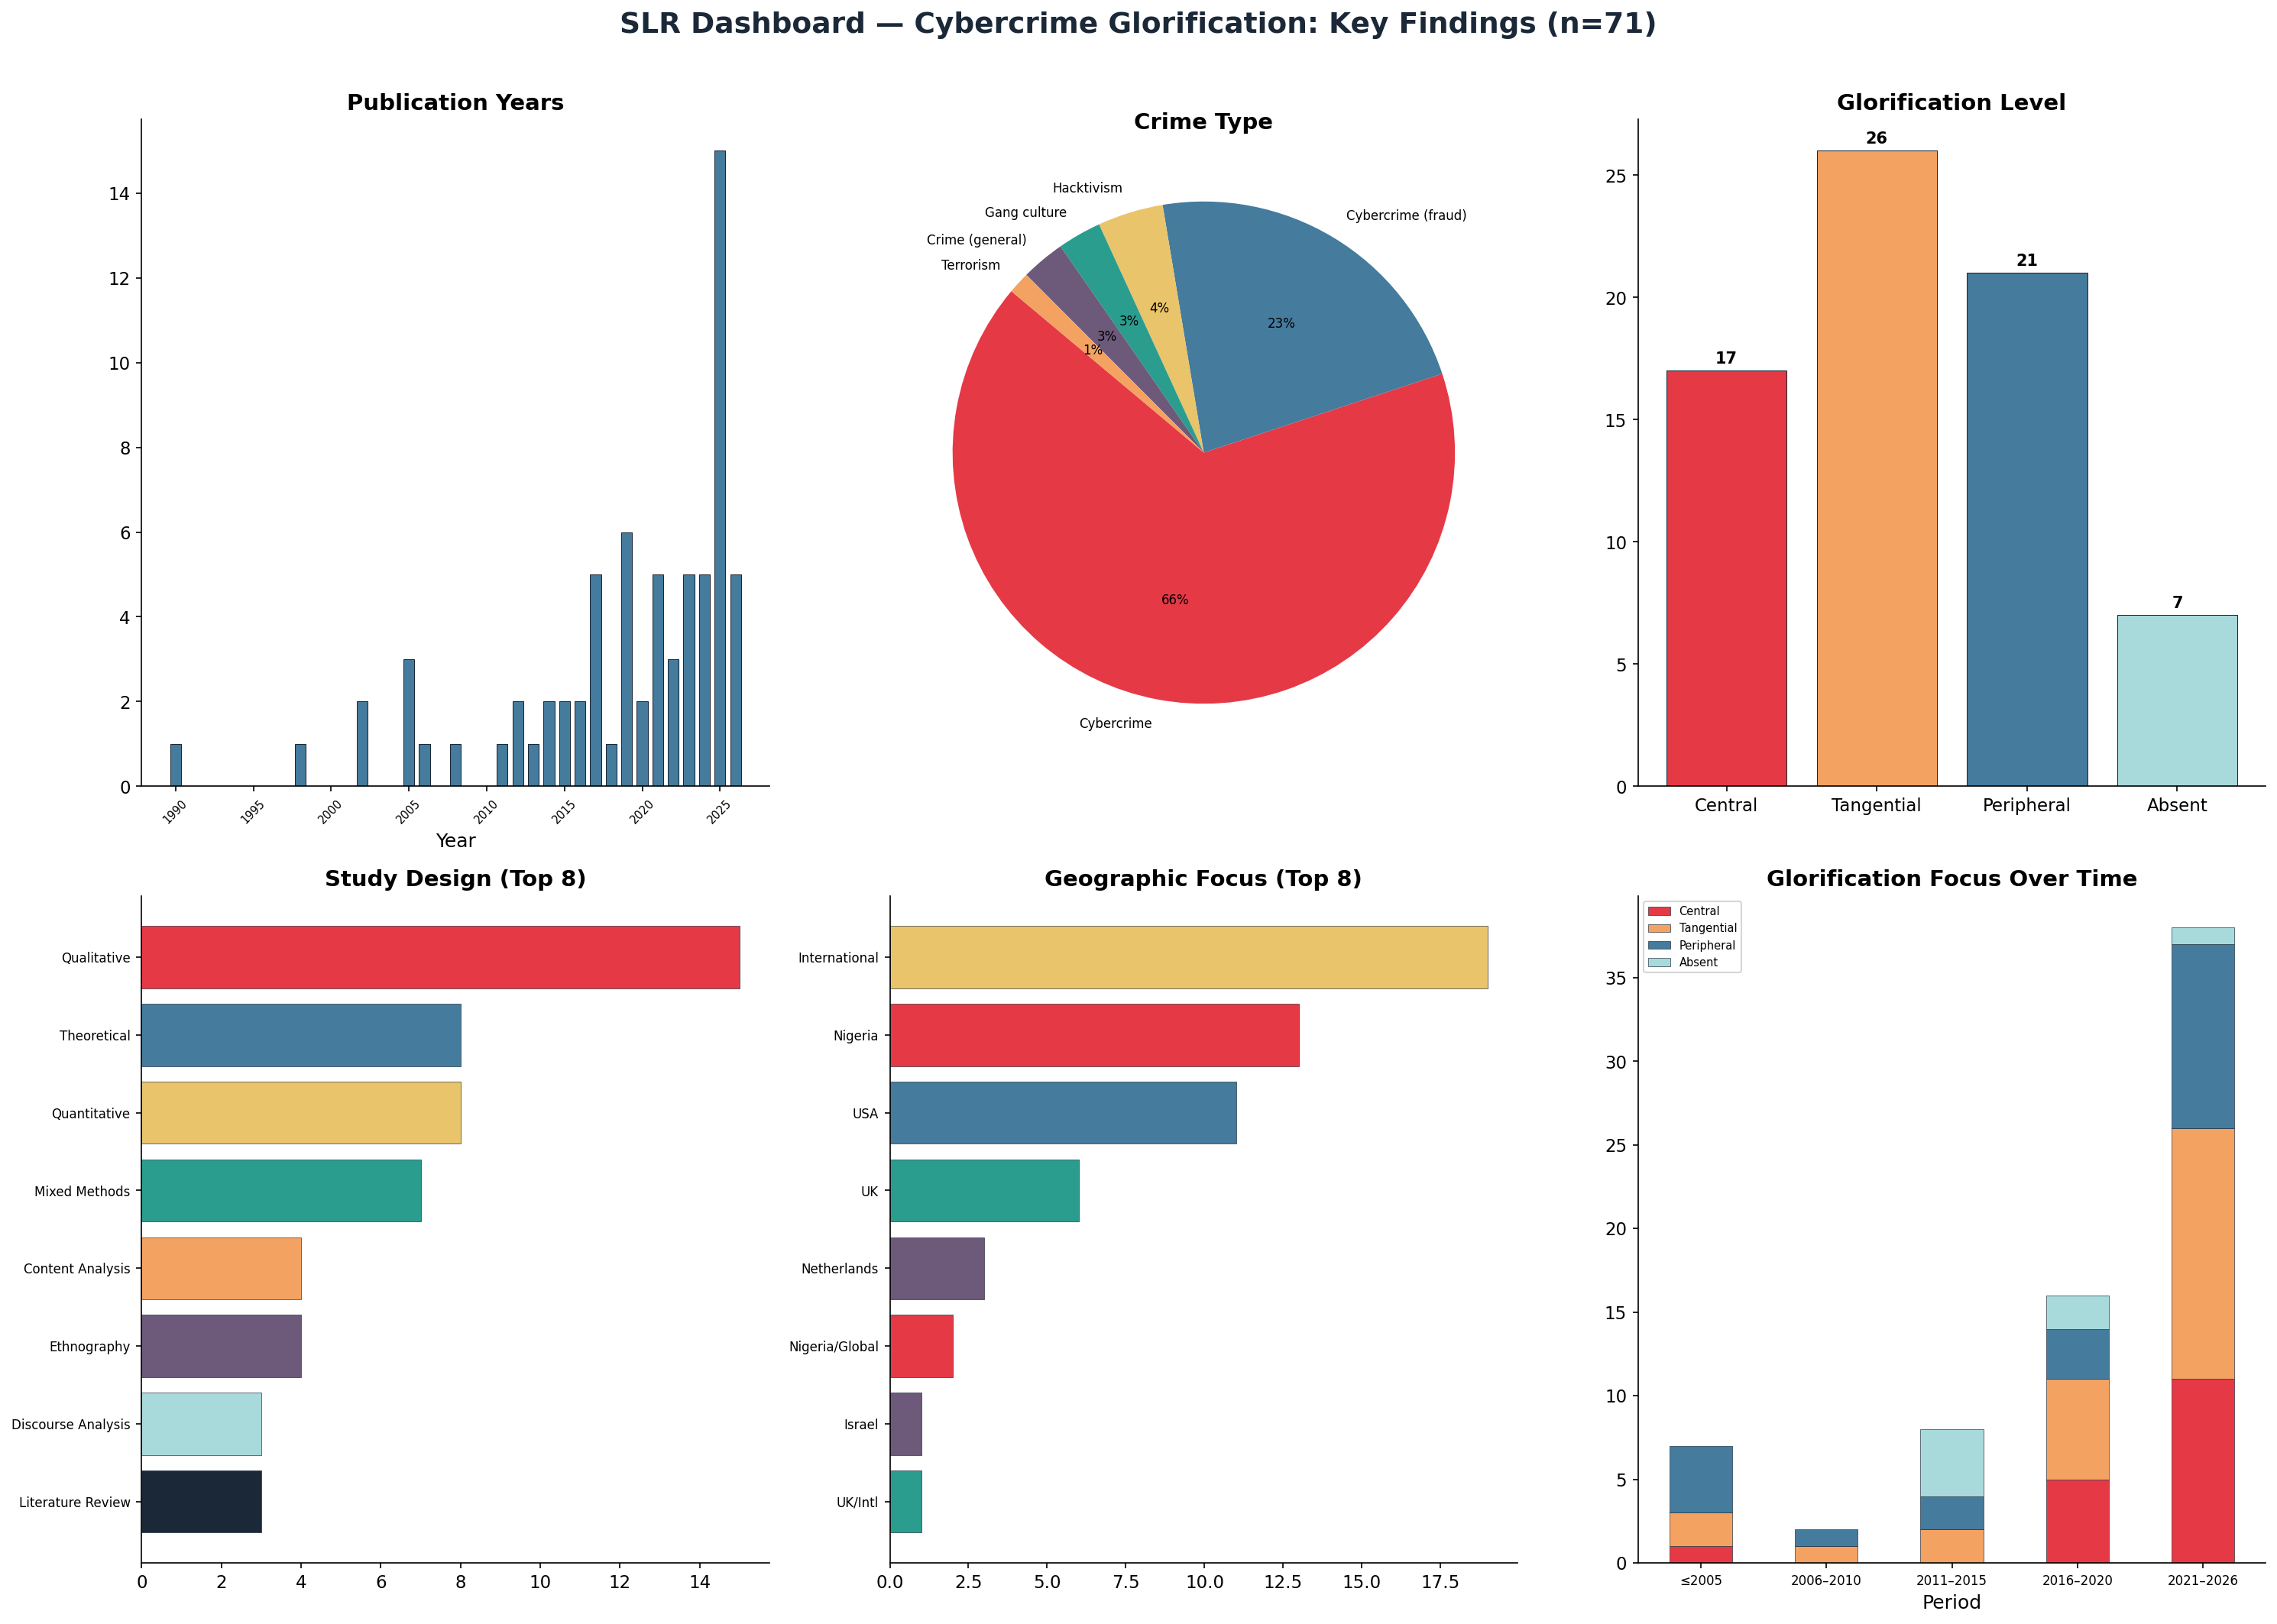


✅ All analyses complete! Charts saved as PNG files.


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('SLR Dashboard — Cybercrime Glorification: Key Findings (n=71)',
             fontsize=18, fontweight='bold', color=COLORS['primary'], y=1.01)

# 1. Year distribution
ax = axes[0, 0]
ax.bar(year_counts.index, year_counts.values, color=COLORS['blue'],
       edgecolor=COLORS['primary'], linewidth=0.5, width=0.7)
ax.set_title('Publication Years', fontweight='bold')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 2. Crime type pie
ax = axes[0, 1]
ax.pie(crime_counts.values, labels=crime_counts.index, autopct='%1.0f%%',
       colors=colors_crime[:len(crime_counts)], startangle=140, textprops={'fontsize': 8})
ax.set_title('Crime Type', fontweight='bold')

# 3. Glorification level bars
ax = axes[0, 2]
glor_ordered = glor_clean.reindex(['Central', 'Tangential', 'Peripheral', 'Absent'])
ax.bar(glor_ordered.index, glor_ordered.values,
       color=[color_map[x] for x in glor_ordered.index],
       edgecolor=COLORS['primary'], linewidth=0.5)
for i, (idx, val) in enumerate(glor_ordered.items()):
    ax.text(i, val + 0.3, str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Glorification Level', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Top designs
ax = axes[1, 0]
top_designs = final_71['Design_Clean'].value_counts().head(8)
ax.barh(top_designs.index[::-1], top_designs.values[::-1],
        color=[PALETTE[i % len(PALETTE)] for i in range(len(top_designs))][::-1],
        edgecolor=COLORS['primary'], linewidth=0.3)
ax.set_title('Study Design (Top 8)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. Top countries
ax = axes[1, 1]
top_countries = country_counts.head(8)
ax.barh(top_countries.index[::-1], top_countries.values[::-1],
        color=[get_region_color(c) for c in top_countries.index][::-1],
        edgecolor=COLORS['primary'], linewidth=0.3)
ax.set_title('Geographic Focus (Top 8)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Temporal glorification stacked
ax = axes[1, 2]
cross_period.plot(kind='bar', stacked=True, color=color_list, ax=ax,
                  edgecolor=COLORS['primary'], linewidth=0.3, legend=True)
ax.set_title('Glorification Focus Over Time', fontweight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('14_dashboard_key_findings.png', bbox_inches='tight', dpi=300)
plt.show()
print('\n✅ All analyses complete! Charts saved as PNG files.')